# 4. Statistical analysis

This block:
1) merges acquisition-level physical derivatives into the harmonised signal table
2) builds the QC-filtered statistical-analysis dataset
3) aggregates repeated acquisitions into analytical units
4) performs descriptive statistics, group comparisons, correlations, and exploratory PCA + clustering

Assumptions:
- Block 1 (preprocessing) has already been executed
- Block 2 (audit) has already been executed
- Block 3 (signal QC) has already been executed
- The following objects already exist:
    - signals_with_visit_df     
    - clinical_long_df
    - signals_qc_df
    - merge_signal_and_clinical(...)
    - NEW_PATIENT_OFFSET
    - plt, pd, np, Path, display

In [129]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 4.1. Merge physical derivatives at acquisition level

In [130]:
PHYSICS_OLD_FILE = "/content/drive/MyDrive/PhD/files_oldcode/patients_oldcode_physics.csv"
PHYSICS_NEW_FILE = "/content/drive/MyDrive/PhD/files_newcode/patients_newcode_physics.csv"

In [131]:
def _clean_token(x):
    """
    Convert a timestamp-like token to a clean string key.
    """
    return str(x).strip() if pd.notna(x) else pd.NA

In [132]:
def _read_table_auto(file_path):
    """
    Read CSV or Excel automatically from file extension.
    """
    suffix = Path(file_path).suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(file_path).copy()
    if suffix in [".xlsx", ".xls"]:
        return pd.read_excel(file_path).copy()

    raise ValueError(f"Unsupported file format: {suffix}")

In [133]:
def _load_old_physics_table(file_path):
    """
    Load the old-code physics table and harmonise its keys.
    """
    df = _read_table_auto(file_path)

    df["global_patient_id"] = pd.to_numeric(df["patient"], errors="coerce").astype("Int64")
    df["site_code"] = df["region"].astype(str).str.strip().str.upper()
    df["measurement_index_site"] = pd.to_numeric(df["iter"], errors="coerce").astype("Int64")
    df["acquisition_token"] = df["timeDateStamps"].map(_clean_token)
    df["protocol_version"] = "old"

    physics_cols = ["c700", "c700_sd", "visc", "visc_sd"]
    physics_cols = [c for c in physics_cols if c in df.columns]

    for col in physics_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    out_cols = [
        "protocol_version",
        "global_patient_id",
        "site_code",
        "measurement_index_site",
        "acquisition_token",
    ] + physics_cols

    df = df.loc[df["site_code"].isin(["A", "B", "P"]), out_cols].copy()
    df = df.dropna(
        subset=[
            "global_patient_id",
            "site_code",
            "measurement_index_site",
            "acquisition_token",
        ]
    )

    return df

In [134]:
def _load_new_physics_table(file_path, new_patient_offset=NEW_PATIENT_OFFSET):
    """
    Load the new-code physics table and harmonise its keys.

    New-code local patient IDs may run from 1..86, while the final
    global IDs used in the study run from 159..244. If needed, the
    offset is applied automatically.
    """
    df = _read_table_auto(file_path)

    df["global_patient_id"] = pd.to_numeric(df["patient"], errors="coerce").astype("Int64")

    max_pid = df["global_patient_id"].dropna().max()
    if pd.notna(max_pid) and max_pid <= 86:
        df["global_patient_id"] = df["global_patient_id"] + new_patient_offset

    df["site_code"] = df["region_anatomica"].astype(str).str.strip().str.upper()

    angle = pd.to_numeric(df["angle"], errors="coerce")
    rep = pd.to_numeric(df["rep"], errors="coerce")
    df["measurement_index_site"] = ((angle - 1) * 2 + rep).astype("Int64")

    df["acquisition_token"] = df["timeDateStamps"].map(_clean_token)
    df["protocol_version"] = "new"

    physics_cols = [
        "c700", "c700_sd", "visc", "visc_sd",
        "nl", "nl_sd",
        "c2000", "c2000_sd",
        "c200", "c200_sd",
    ]
    physics_cols = [c for c in physics_cols if c in df.columns]

    for col in physics_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    out_cols = [
        "protocol_version",
        "global_patient_id",
        "site_code",
        "measurement_index_site",
        "acquisition_token",
    ] + physics_cols

    df = df.loc[df["site_code"].isin(["A", "B", "P"]), out_cols].copy()
    df = df.dropna(
        subset=[
            "global_patient_id",
            "site_code",
            "measurement_index_site",
            "acquisition_token",
        ]
    )

    return df


In [135]:
def _build_physics_table(old_file_path, new_file_path):
    """
    Build one harmonised physics table across protocols.
    Duplicate rows for the same acquisition are collapsed conservatively.
    """
    old_df = _load_old_physics_table(old_file_path)
    new_df = _load_new_physics_table(new_file_path)

    physics_df = pd.concat([old_df, new_df], ignore_index=True)

    key_cols = [
        "protocol_version",
        "global_patient_id",
        "site_code",
        "measurement_index_site",
        "acquisition_token",
    ]
    value_cols = [c for c in physics_df.columns if c not in key_cols]

    physics_df = (
        physics_df
        .sort_values(key_cols)
        .groupby(key_cols, as_index=False)[value_cols]
        .first()
    )

    return physics_df

In [136]:
physics_df = _build_physics_table(
    old_file_path=PHYSICS_OLD_FILE,
    new_file_path=PHYSICS_NEW_FILE,
)

print("\nPhysics table preview")
display(physics_df.head())


Physics table preview


,protocol_version,global_patient_id,site_code,measurement_index_site,acquisition_token,c700,c700_sd,visc,visc_sd,nl,nl_sd,c2000,c2000_sd,c200,c200_sd
0,new,159,A,1,23_03_25_09_48_52,19.938405,1.878686e-01,11.343707,1.310624e+00,5.619288,1.147162,28.400941,1.486071,NaN,0.877502
1,new,159,A,2,23_03_25_09_49_10,5.468750,4.863557e+06,7.812500,4.863557e+07,4.392427,1.286729,37.816525,2.130867,NaN,1.144851
2,new,159,A,3,23_03_25_09_49_26,5.268424,6.682583e-01,1.384678,4.694067e+00,5.673163,1.150929,45.535821,2.553261,NaN,1.392005
3,new,159,A,4,23_03_25_09_49_42,6.431017,2.940673e-01,13.901736,2.014163e+00,4.823512,1.428067,41.981938,2.326726,7.850304,1.148225
4,new,159,A,5,23_03_25_09_49_57,3.265625,1.448075e+06,-3.906250,1.448075e+07,4.359839,1.289055,18.646274,0.871938,NaN,0.501160


In [137]:
print("\nPhysics table columns")
print(physics_df.columns.tolist())


Physics table columns
['protocol_version', 'global_patient_id', 'site_code', 'measurement_index_site', 'acquisition_token', 'c700', 'c700_sd', 'visc', 'visc_sd', 'nl', 'nl_sd', 'c2000', 'c2000_sd', 'c200', 'c200_sd']


In [138]:
physics_merge_keys = [
    "protocol_version",
    "global_patient_id",
    "site_code",
    "measurement_index_site",
    "acquisition_token",
]

In [139]:
# If this section is re-run, remove previously merged physics columns first.
physics_cols_present_before_merge = [c for c in physics_df.columns if c not in physics_merge_keys]

In [140]:
signals_with_visit_df = signals_with_visit_df.drop(
    columns=[c for c in physics_cols_present_before_merge if c in signals_with_visit_df.columns],
    errors="ignore",
)

In [141]:
signals_with_visit_df = signals_with_visit_df.merge(
    physics_df,
    on=physics_merge_keys,
    how="left",
)

### 4.1.1. Rebuild the signal + clinical table after adding physics

In [142]:
signals_clinical_df = merge_signal_and_clinical(
    signals_with_visit_df=signals_with_visit_df,
    clinical_long_df=clinical_long_df,
)

In [143]:
print("\nCoverage of physical variables in signals_with_visit_df")
physics_coverage_cols = [
    c for c in [
        "c700", "c700_sd", "visc", "visc_sd",
        "nl", "nl_sd", "c2000", "c2000_sd", "c200", "c200_sd",
    ]
    if c in signals_with_visit_df.columns
]

display(
    signals_with_visit_df[physics_coverage_cols]
    .notna()
    .mean()
    .mul(100)
    .round(2)
    .rename("pct_non_missing")
    .reset_index()
    .rename(columns={"index": "variable"})
)


Coverage of physical variables in signals_with_visit_df


,variable,pct_non_missing
0,c700,97.88
1,c700_sd,97.88
2,visc,99.34
3,visc_sd,99.97
4,nl,45.24
5,nl_sd,45.24
6,c2000,44.89
7,c2000_sd,45.24
8,c200,15.05
9,c200_sd,45.24


In [144]:
print("\nCore physical variables present in signals_clinical_df")
print([c for c in ["c700", "c700_sd", "visc", "visc_sd"] if c in signals_clinical_df.columns])


Core physical variables present in signals_clinical_df
['c700', 'c700_sd', 'visc', 'visc_sd']


## 4.2. Build the statistical-analysis dataset

In [145]:
def _first_non_null(series):
    """
    Return the first non-missing value in a series.
    This is useful when aggregating static or categorical variables.
    """
    valid = series.dropna()
    return valid.iloc[0] if len(valid) > 0 else pd.NA

In [146]:
def _sex_to_female_binary(series):
    """
    Convert the sex variable to a binary representation:
    - 1 for female
    - 0 for male
    - <NA> if unknown
    """
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().any():
        return numeric.astype("Int64")

    text = series.astype(str).str.strip().str.upper()
    mapping = {
        "H": 0, "HOMBRE": 0, "MALE": 0, "MASCULINO": 0, "MASC": 0,
        "M": 1, "MUJER": 1, "FEMALE": 1, "FEMENINO": 1, "FEM": 1,
    }
    return pd.to_numeric(text.map(mapping), errors="coerce").astype("Int64")

In [147]:
def _add_cardiometabolic_flags(df):
    """
    Add binary cardiometabolic indicators using standard thresholds.

    Added variables:
    - abdominal_obesity
    - high_triglycerides
    - low_hdl
    - hypertension
    - high_glucose
    - metabolic_syndrome
    """
    out = df.copy()

    numeric_cols = [
        "BC_WC_mean",
        "BLOB_TG",
        "BLOB_HDL",
        "BP_SBP_ave",
        "BP_DBP_ave",
        "BLOB_Gluc",
    ]
    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    if "Sex" in out.columns:
        out["_female"] = _sex_to_female_binary(out["Sex"])
    else:
        out["_female"] = pd.Series([pd.NA] * len(out), dtype="Int64")

    male = out["_female"] == 0
    female = out["_female"] == 1

    out["abdominal_obesity"] = (
        (male & (out["BC_WC_mean"] > 102)) |
        (female & (out["BC_WC_mean"] > 88))
    ).astype("Int64")

    out["high_triglycerides"] = (out["BLOB_TG"] > 150).astype("Int64")

    out["low_hdl"] = (
        (male & (out["BLOB_HDL"] < 40)) |
        (female & (out["BLOB_HDL"] < 50))
    ).astype("Int64")

    out["hypertension"] = (
        (out["BP_SBP_ave"] > 130) | (out["BP_DBP_ave"] > 85)
    ).astype("Int64")

    out["high_glucose"] = (out["BLOB_Gluc"] > 100).astype("Int64")

    out["metabolic_syndrome"] = (
        out[
            [
                "abdominal_obesity",
                "high_triglycerides",
                "low_hdl",
                "hypertension",
                "high_glucose",
            ]
        ]
        .fillna(0)
        .sum(axis=1) >= 3
    ).astype("Int64")

    out = out.drop(columns=["_female"], errors="ignore")
    return out

### 4.2.1. Merge QC information into the signal + clinical + physics table

In [148]:
qc_cols_to_merge = [
    "signal_record_id",
    "qc_decision",
    "qc_flag_count",
    "qc_reason",
    "qc_n_channels_used",
    "p2p_median",
    "rms_median",
    "drift_ratio_median",
    "roughness_ratio_median",
]
qc_cols_to_merge = [c for c in qc_cols_to_merge if c in signals_qc_df.columns]

In [149]:
stat_base_df = signals_clinical_df.merge(
    signals_qc_df[qc_cols_to_merge],
    on="signal_record_id",
    how="left",
)

### 4.2.2. Keep only acquisitions accepted for downstream analysis

In [150]:
# "keep" and "review" are retained; "exclude" is dropped.
stat_base_df = stat_base_df.loc[
    stat_base_df["qc_decision"].isin(["keep", "review"])
].copy()

### 4.2.3. Add cardiometabolic flags

In [151]:
stat_base_df = _add_cardiometabolic_flags(stat_base_df)

### 4.2.4. Define the structure of the final analytical unit


In [152]:
group_keys = [
    "global_patient_id",
    "hospital_patient_id",
    "protocol_version",
    "timepoint",
    "site_code",
]

### 4.2.5. Main physical variables shared across protocols

In [153]:
primary_physics_cols = [
    "c700",
    "c700_sd",
    "visc",
    "visc_sd",
]
primary_physics_cols = [c for c in primary_physics_cols if c in stat_base_df.columns]

### 4.2.6. Extended physical variables, mainly available in new code

In [154]:
extended_physics_cols = [
    "nl",
    "nl_sd",
    "c2000",
    "c2000_sd",
    "c200",
    "c200_sd",
]
extended_physics_cols = [c for c in extended_physics_cols if c in stat_base_df.columns]

### 4.2.7. Signal-derived QC and morphology summaries

In [155]:
signal_summary_cols = [
    "qc_n_channels_used",
    "p2p_median",
    "rms_median",
    "drift_ratio_median",
    "roughness_ratio_median",
]
signal_summary_cols = [c for c in signal_summary_cols if c in stat_base_df.columns]

### 4.2.8. Continuous clinical variables

In [156]:
clinical_continuous_cols = [
    "Age",
    "BC_WC_mean",
    "BLOB_TG",
    "BLOB_HDL",
    "BP_SBP_ave",
    "BP_DBP_ave",
    "BLOB_Gluc",
]
clinical_continuous_cols = [c for c in clinical_continuous_cols if c in stat_base_df.columns]

### 4.2.9. Binary cardiometabolic variables

In [157]:
clinical_binary_cols = [
    "abdominal_obesity",
    "high_triglycerides",
    "low_hdl",
    "hypertension",
    "high_glucose",
    "metabolic_syndrome",
]
clinical_binary_cols = [c for c in clinical_binary_cols if c in stat_base_df.columns]

### 4.2.10. Static variables

In [158]:
static_cols = [c for c in ["Sex"] if c in stat_base_df.columns]

## 4.3. Aggregate repeated acquisitions

### 4.3.1. Build the aggregation dictionary

In [159]:
# Continuous variables are aggregated with the median
# because it is more robust to outliers and repeated acquisitions.
agg_dict = {
    "signal_record_id": "nunique",
}

if "qc_flag_count" in stat_base_df.columns:
    agg_dict["qc_flag_count"] = "median"

for col in primary_physics_cols + extended_physics_cols + signal_summary_cols + clinical_continuous_cols:
    agg_dict[col] = "median"

for col in clinical_binary_cols + static_cols:
    agg_dict[col] = _first_non_null

### 4.3.2. Aggregate repeated acquisitions into one analytical unit

In [160]:
stat_analysis_df = (
    stat_base_df
    .groupby(group_keys, as_index=False)
    .agg(agg_dict)
    .rename(columns={"signal_record_id": "n_acquisitions_retained"})
)

### 4.3.3. Create an explicit analysis-unit identifier

In [161]:
stat_analysis_df["analysis_unit_id"] = (
    "unit_" + stat_analysis_df.index.astype(str).str.zfill(6)
)

### 4.3.4. Reorder columns for readability

In [162]:
ordered_cols = (
    ["analysis_unit_id"]
    + group_keys
    + ["n_acquisitions_retained"]
    + primary_physics_cols
    + extended_physics_cols
    + signal_summary_cols
    + clinical_continuous_cols
    + clinical_binary_cols
    + static_cols
    + (["qc_flag_count"] if "qc_flag_count" in stat_analysis_df.columns else [])
)
ordered_cols = [c for c in ordered_cols if c in stat_analysis_df.columns]
stat_analysis_df = stat_analysis_df[ordered_cols].copy()

### 4.3.5. Quick previews

In [163]:
print("\nStatistical analysis base table (QC-filtered acquisitions)")
base_preview_cols = [
    "signal_record_id",
    "global_patient_id",
    "hospital_patient_id",
    "protocol_version",
    "timepoint",
    "site_code",
    "qc_decision",
] + [c for c in primary_physics_cols + signal_summary_cols if c in stat_base_df.columns]
display(stat_base_df[base_preview_cols].head(20))


Statistical analysis base table (QC-filtered acquisitions)


,signal_record_id,global_patient_id,hospital_patient_id,protocol_version,timepoint,site_code,qc_decision,c700,c700_sd,visc,visc_sd,qc_n_channels_used,p2p_median,rms_median,drift_ratio_median,roughness_ratio_median
0,sig_000006,159,579,new,FUP,B,keep,11.150700,1.210360e-01,3.362049,8.195324e-01,9,3.253757,0.409288,0.015423,0.031952
1,sig_000007,159,579,new,FUP,B,keep,11.521770,1.185510e-01,3.609879,9.524552e-01,9,3.413835,0.436061,0.003637,0.032208
2,sig_000008,159,579,new,FUP,B,keep,13.977223,1.617192e-01,5.647441,1.076234e+00,9,3.207032,0.353959,0.002109,0.032964
3,sig_000009,159,579,new,FUP,B,keep,9.464186,8.039239e-02,3.413286,5.401912e-01,9,2.917012,0.408117,0.004510,0.033237
4,sig_000010,159,579,new,FUP,B,keep,10.630767,7.192197e-02,2.839507,4.813204e-01,9,2.888546,0.274068,0.023516,0.027477
5,sig_000011,159,579,new,FUP,B,keep,15.291667,8.875088e+06,10.416667,8.875088e+07,9,2.729402,0.327400,0.009092,0.029078
6,sig_000012,159,579,new,FUP,P,keep,9.317635,9.990101e-02,6.918945,7.684015e-01,9,1.073773,0.293037,0.007793,0.043507
7,sig_000013,159,579,new,FUP,P,keep,4.330034,2.358165e-01,4.544945,1.981055e+00,9,1.117992,0.136358,0.010941,0.038369
8,sig_000014,159,579,new,FUP,P,keep,6.937500,0.000000e+00,15.625000,0.000000e+00,9,0.516262,0.105731,0.037941,0.058742
9,sig_000015,159,579,new,FUP,P,keep,8.477615,9.562301e-02,3.825082,7.337468e-01,9,0.388629,0.095815,0.024650,0.056353


In [164]:
print("\nStatistical analysis table (aggregated analytical units)")
display(stat_analysis_df.head(20))


Statistical analysis table (aggregated analytical units)


,analysis_unit_id,global_patient_id,hospital_patient_id,protocol_version,timepoint,site_code,n_acquisitions_retained,c700,c700_sd,visc,...,BP_DBP_ave,BLOB_Gluc,abdominal_obesity,high_triglycerides,low_hdl,hypertension,high_glucose,metabolic_syndrome,Sex,qc_flag_count
0,unit_000000,1,540,old,POST,A,3,3.642783,0.041739,2.210272,...,83.5,93.0,1,0,0,0,0,0,1.0,0.0
1,unit_000001,1,540,old,POST,B,3,6.231740,0.003354,4.121518,...,83.5,93.0,1,0,0,0,0,0,1.0,0.0
2,unit_000002,1,540,old,POST,P,3,6.656508,0.011868,4.252347,...,83.5,93.0,1,0,0,0,0,0,1.0,0.0
3,unit_000003,2,533,old,POST,A,3,5.668760,0.046051,5.282341,...,84.5,93.0,1,0,0,0,0,0,0.0,0.0
4,unit_000004,2,533,old,POST,B,3,6.873288,0.048042,5.023496,...,84.5,93.0,1,0,0,0,0,0,0.0,1.0
5,unit_000005,2,533,old,POST,P,4,7.944970,0.032651,4.258404,...,84.5,93.0,1,0,0,0,0,0,0.0,0.0
6,unit_000006,3,534,old,POST,A,3,4.837798,0.028186,3.899580,...,80.0,76.0,1,0,0,0,0,0,1.0,0.0
7,unit_000007,3,534,old,POST,B,3,5.423227,0.028148,3.932779,...,80.0,76.0,1,0,0,0,0,0,1.0,0.0
8,unit_000008,3,534,old,POST,P,3,6.404198,0.013474,2.577656,...,80.0,76.0,1,0,0,0,0,0,1.0,0.0
9,unit_000009,4,535,old,POST,A,3,3.527665,0.028270,1.915193,...,83.5,81.0,0,0,0,0,0,0,0.0,0.0


In [165]:
print("\nNumber of analytical units by protocol and site")
display(
    stat_analysis_df
    .groupby(["protocol_version", "site_code"], as_index=False)
    .size()
    .rename(columns={"size": "n_analysis_units"})
    .sort_values(["protocol_version", "site_code"])
)


Number of analytical units by protocol and site


,protocol_version,site_code,n_analysis_units
0,new,A,86
1,new,B,86
2,new,P,86
3,old,A,157
4,old,B,156
5,old,P,157


In [166]:
if "metabolic_syndrome" in stat_analysis_df.columns:
    print("\nNumber of analytical units by metabolic syndrome")
    display(
        stat_analysis_df["metabolic_syndrome"]
        .value_counts(dropna=False)
        .rename_axis("metabolic_syndrome")
        .reset_index(name="n_units")
    )




Number of analytical units by metabolic syndrome


,metabolic_syndrome,n_units
0,0,572
1,1,156


In [167]:
print("\nMedian number of retained acquisitions per analytical unit")
display(
    stat_analysis_df
    .groupby(["protocol_version", "site_code"], as_index=False)["n_acquisitions_retained"]
    .median()
    .rename(columns={"n_acquisitions_retained": "median_n_acquisitions_retained"})
    .sort_values(["protocol_version", "site_code"])
)


Median number of retained acquisitions per analytical unit


,protocol_version,site_code,median_n_acquisitions_retained
0,new,A,6.0
1,new,B,6.0
2,new,P,6.0
3,old,A,4.0
4,old,B,3.0
5,old,P,4.0


### 4.3.6. Summarise the transition from raw acquisitions to analytical units

In [168]:
raw_n = len(signals_with_visit_df)
keep_n = int((signals_qc_df["qc_decision"] == "keep").sum())
review_n = int((signals_qc_df["qc_decision"] == "review").sum())
exclude_n = int((signals_qc_df["qc_decision"] == "exclude").sum())
retained_n = keep_n + review_n
final_n = len(stat_analysis_df)

summary_df = pd.DataFrame({
    "stage": [
        "raw acquisitions",
        "retained after QC",
        "excluded by QC",
        "final analytical units",
    ],
    "n": [
        raw_n,
        retained_n,
        exclude_n,
        final_n,
    ],
})
summary_df["pct_vs_raw"] = 100 * summary_df["n"] / raw_n

print("\nAcquisition-to-analysis summary")
display(summary_df)


Acquisition-to-analysis summary


,stage,n,pct_vs_raw
0,raw acquisitions,3495,100.000000
1,retained after QC,3359,96.108727
2,excluded by QC,136,3.891273
3,final analytical units,728,20.829757


## 4.4. Descriptive statistics and group comparisons

In [169]:
# Define variable families for downstream analyses
PRIMARY_MECHANICAL_VARS = primary_physics_cols.copy()
SECONDARY_MECHANICAL_VARS = signal_summary_cols.copy()
ALL_MECHANICAL_VARS = PRIMARY_MECHANICAL_VARS + SECONDARY_MECHANICAL_VARS

RISK_FLAG_VARS = clinical_binary_cols.copy()
CLINICAL_CONTINUOUS_VARS = clinical_continuous_cols.copy()

SITE_ORDER = ["A", "B", "P"]
SITE_ORDER = [s for s in SITE_ORDER if s in stat_analysis_df["site_code"].dropna().unique()]

In [170]:
# Prefer the main physical variables for visual comparison
# If they are not available, fall back to simple signal-derived summaries.
PLOT_VARS = [c for c in ["c700", "visc"] if c in stat_analysis_df.columns]
if len(PLOT_VARS) == 0:
    PLOT_VARS = [c for c in ["p2p_median", "rms_median"] if c in stat_analysis_df.columns]

In [171]:
# Create a numeric working copy
stat_work_df = stat_analysis_df.copy()

for col in ALL_MECHANICAL_VARS + extended_physics_cols + CLINICAL_CONTINUOUS_VARS + RISK_FLAG_VARS:
    if col in stat_work_df.columns:
        stat_work_df[col] = pd.to_numeric(stat_work_df[col], errors="coerce")

### 4.4.1. Variable-level descriptive summary

In [172]:
variable_summary_rows = []

for col in ALL_MECHANICAL_VARS + extended_physics_cols + CLINICAL_CONTINUOUS_VARS:
    if col not in stat_work_df.columns:
        continue

    series = stat_work_df[col].dropna()

    variable_summary_rows.append({
        "variable": col,
        "n_non_missing": int(series.shape[0]),
        "pct_non_missing": 100 * series.shape[0] / len(stat_work_df),
        "mean": float(series.mean()) if len(series) > 0 else np.nan,
        "sd": float(series.std()) if len(series) > 1 else np.nan,
        "median": float(series.median()) if len(series) > 0 else np.nan,
        "q1": float(series.quantile(0.25)) if len(series) > 0 else np.nan,
        "q3": float(series.quantile(0.75)) if len(series) > 0 else np.nan,
        "min": float(series.min()) if len(series) > 0 else np.nan,
        "max": float(series.max()) if len(series) > 0 else np.nan,
    })

stat_variable_summary_df = (
    pd.DataFrame(variable_summary_rows)
    .sort_values("variable")
    .reset_index(drop=True)
)

### 4.4.2. Site-level summary for main mechanical variables

In [173]:
site_summary_vars = PRIMARY_MECHANICAL_VARS + [
    c for c in ["p2p_median", "rms_median"] if c in stat_work_df.columns
]

site_long_df = (
    stat_work_df.melt(
        id_vars=["site_code"],
        value_vars=site_summary_vars,
        var_name="variable",
        value_name="value",
    )
    .dropna(subset=["value"])
    .copy()
)

site_mechanical_summary_df = (
    site_long_df.groupby(["site_code", "variable"], as_index=False)
    .agg(
        n=("value", "size"),
        mean=("value", "mean"),
        sd=("value", "std"),
        median=("value", "median"),
        q1=("value", lambda s: s.quantile(0.25)),
        q3=("value", lambda s: s.quantile(0.75)),
    )
    .sort_values(["variable", "site_code"])
    .reset_index(drop=True)
)

### 4.4.3. Group comparisons by risk flag and anatomical site

In [174]:
# Use non-parametric testing because the mechanical variables
# are not assumed to follow a Gaussian distribution.
comparison_rows = []
site_levels = ["ALL"] + SITE_ORDER

comparison_vars = PRIMARY_MECHANICAL_VARS + [
    c for c in ["p2p_median", "rms_median", "drift_ratio_median", "roughness_ratio_median"]
    if c in stat_work_df.columns
]

for flag_var in RISK_FLAG_VARS:
    for mech_var in comparison_vars:
        if mech_var not in stat_work_df.columns:
            continue

        for site_code in site_levels:
            if site_code == "ALL":
                subset_df = stat_work_df[[mech_var, flag_var]].dropna().copy()
            else:
                subset_df = stat_work_df.loc[
                    stat_work_df["site_code"] == site_code,
                    [mech_var, flag_var]
                ].dropna().copy()

            if subset_df.empty:
                continue

            group_0 = subset_df.loc[subset_df[flag_var] == 0, mech_var].dropna()
            group_1 = subset_df.loc[subset_df[flag_var] == 1, mech_var].dropna()

            # Require a minimum size in both groups
            if (len(group_0) < 5) or (len(group_1) < 5):
                continue

            u_stat, p_value = mannwhitneyu(group_0, group_1, alternative="two-sided")

            comparison_rows.append({
                "risk_flag": flag_var,
                "site_code": site_code,
                "mechanical_variable": mech_var,
                "n_group_0": int(len(group_0)),
                "n_group_1": int(len(group_1)),
                "median_group_0": float(group_0.median()),
                "median_group_1": float(group_1.median()),
                "delta_median_1_minus_0": float(group_1.median() - group_0.median()),
                "u_statistic": float(u_stat),
                "p_value": float(p_value),
            })

group_comparison_df = pd.DataFrame(comparison_rows)

In [175]:
# Correct for multiple testing using Benjamini-Hochberg FDR
if not group_comparison_df.empty:
    group_comparison_df["p_fdr"] = multipletests(
        group_comparison_df["p_value"].values,
        method="fdr_bh",
    )[1]
    group_comparison_df["significant_fdr_05"] = group_comparison_df["p_fdr"] < 0.05
    group_comparison_df = group_comparison_df.sort_values(
        ["p_fdr", "risk_flag", "mechanical_variable", "site_code"]
    ).reset_index(drop=True)

### 4.4.4. Spearman correlation matrix

In [176]:
corr_vars = [
    c for c in (
        PRIMARY_MECHANICAL_VARS
        + [c for c in ["p2p_median", "rms_median", "drift_ratio_median", "roughness_ratio_median"] if c in stat_work_df.columns]
        + CLINICAL_CONTINUOUS_VARS
    )
    if c in stat_work_df.columns
]

spearman_corr_df = pd.DataFrame()
if len(corr_vars) >= 2:
    spearman_corr_df = stat_work_df[corr_vars].corr(method="spearman")

### 4.4.5. Visualisations

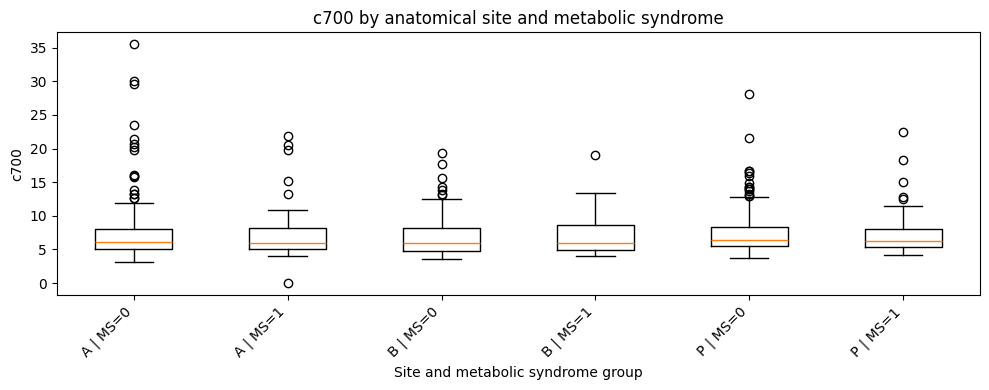

visc: plot-only filtering applied (lower=-1.128, upper=10.137)


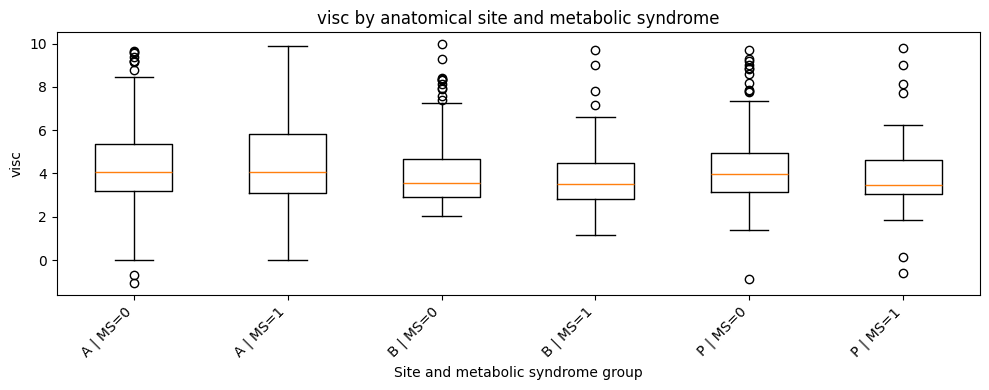

In [177]:
# Boxplots of selected mechanical variables by site and metabolic syndrome
if ("metabolic_syndrome" in stat_work_df.columns) and (len(PLOT_VARS) > 0):
    for plot_var in PLOT_VARS:
        plot_df = stat_work_df.loc[
            stat_work_df[plot_var].notna()
            & stat_work_df["metabolic_syndrome"].notna()
            & stat_work_df["site_code"].notna(),
            ["site_code", "metabolic_syndrome", plot_var]
        ].copy()

        # Plot-only robust filtering for extreme visc values
        if plot_var == "visc":
            q1 = plot_df[plot_var].quantile(0.25)
            q3 = plot_df[plot_var].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr

            plot_df = plot_df.loc[
                plot_df[plot_var].between(lower_bound, upper_bound)
            ].copy()

            print(
                f"{plot_var}: plot-only filtering applied "
                f"(lower={lower_bound:.3f}, upper={upper_bound:.3f})"
            )

        categories = []
        values = []

        for site_code in SITE_ORDER:
            for ms_value in [0, 1]:
                subset_values = plot_df.loc[
                    (plot_df["site_code"] == site_code)
                    & (plot_df["metabolic_syndrome"] == ms_value),
                    plot_var
                ].dropna().values

                if len(subset_values) == 0:
                    continue

                categories.append(f"{site_code} | MS={ms_value}")
                values.append(subset_values)

        if len(values) > 0:
            fig, ax = plt.subplots(figsize=(10, 4))
            ax.boxplot(values, tick_labels=categories)
            ax.set_title(f"{plot_var} by anatomical site and metabolic syndrome")
            ax.set_xlabel("Site and metabolic syndrome group")
            ax.set_ylabel(plot_var)
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()

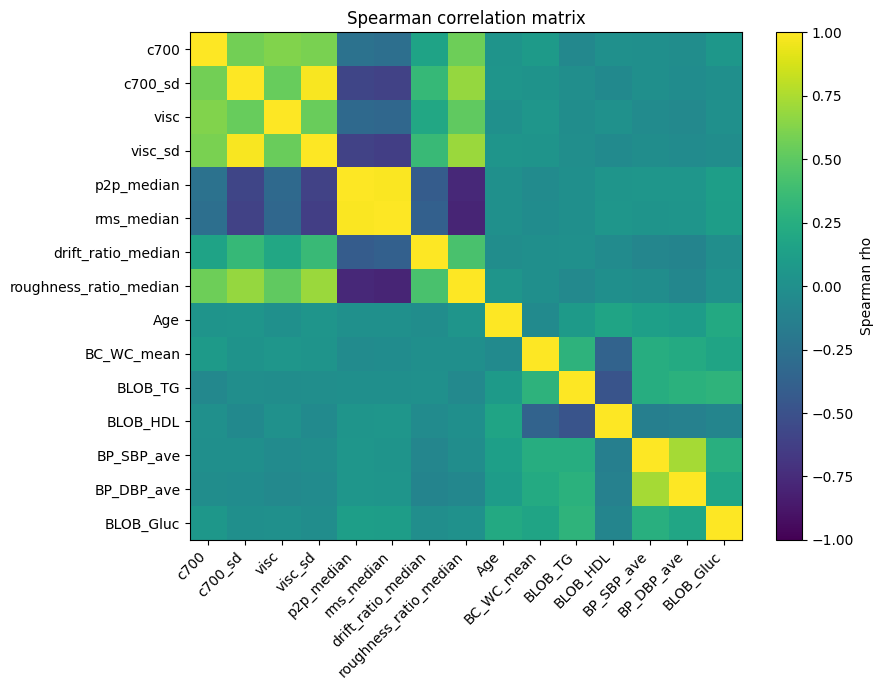

In [178]:
# Heatmap of Spearman correlations
if not spearman_corr_df.empty:
    fig, ax = plt.subplots(figsize=(9, 7))
    image = ax.imshow(spearman_corr_df.values, aspect="auto", vmin=-1, vmax=1)

    ax.set_title("Spearman correlation matrix")
    ax.set_xticks(range(len(spearman_corr_df.columns)))
    ax.set_xticklabels(spearman_corr_df.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(spearman_corr_df.index)))
    ax.set_yticklabels(spearman_corr_df.index)

    cbar = plt.colorbar(image, ax=ax)
    cbar.set_label("Spearman rho")

    plt.tight_layout()
    plt.show()

In [179]:
# Display summary tables
print("\nVariable-level descriptive summary")
display(stat_variable_summary_df)

print("\nSite-level summary for mechanical variables")
display(site_mechanical_summary_df)

print("\nGroup comparisons by risk flag and anatomical site")
display(group_comparison_df.head(50) if not group_comparison_df.empty else pd.DataFrame())

print("\nSignificant group comparisons after FDR correction")
display(
    group_comparison_df.loc[group_comparison_df["significant_fdr_05"]].head(50)
    if not group_comparison_df.empty else pd.DataFrame()
)

print("\nSpearman correlation matrix")
display(spearman_corr_df if not spearman_corr_df.empty else pd.DataFrame())



Variable-level descriptive summary


,variable,n_non_missing,pct_non_missing,mean,sd,median,q1,q3,min,max
0,Age,728,100.000000,48.457418,8.840220e+00,49.000000,43.000000,55.000000,26.000000,6.500000e+01
1,BC_WC_mean,722,99.175824,102.836288,1.072018e+01,102.350000,95.300000,109.350000,76.250000,1.396000e+02
2,BLOB_Gluc,716,98.351648,89.804469,9.904765e+00,89.000000,83.000000,96.000000,67.000000,1.240000e+02
3,BLOB_HDL,707,97.115385,51.922207,1.168282e+01,50.000000,44.000000,58.000000,27.000000,8.900000e+01
4,BLOB_TG,716,98.351648,104.023743,5.278165e+01,92.000000,65.000000,129.250000,36.000000,3.600000e+02
5,BP_DBP_ave,722,99.175824,81.288089,8.425786e+00,80.500000,75.500000,87.000000,62.500000,1.080000e+02
6,BP_SBP_ave,722,99.175824,114.108033,1.253185e+01,113.500000,104.500000,124.000000,87.000000,1.525000e+02
7,c200,232,31.868132,18.957032,6.719842e+01,5.593343,4.041731,8.286282,1.759076,6.648435e+02
8,c2000,258,35.439560,18.505196,6.036565e+00,16.380890,14.750489,20.286902,9.446283,4.287699e+01
9,c2000_sd,258,35.439560,1.691771,1.139064e+00,1.468651,0.913707,2.028968,0.383693,1.053789e+01



Site-level summary for mechanical variables


,site_code,variable,n,mean,sd,median,q1,q3
0,A,c700,243,7.418137,4.443989e+00,6.072550,5.038614,8.007456
1,B,c700,242,6.886165,2.743190e+00,5.886850,4.848011,8.291155
2,P,c700,243,7.527606,3.311713e+00,6.382487,5.424796,8.342208
3,A,c700_sd,243,0.154844,1.940981e-01,0.071028,0.019271,0.231747
4,B,c700_sd,242,0.252030,1.183963e+00,0.066964,0.014477,0.181065
5,P,c700_sd,243,47323.073265,5.385705e+05,0.059820,0.017202,0.204053
6,A,p2p_median,243,4.777872,3.132711e+00,4.951190,1.280549,7.867380
7,B,p2p_median,242,4.736996,3.344946e+00,5.874317,0.626709,7.834802
8,P,p2p_median,243,4.536119,3.233882e+00,4.945161,0.724054,7.482487
9,A,rms_median,243,0.815928,5.751318e-01,0.796006,0.192635,1.354697



Group comparisons by risk flag and anatomical site


,risk_flag,site_code,mechanical_variable,n_group_0,n_group_1,median_group_0,median_group_1,delta_median_1_minus_0,u_statistic,p_value,p_fdr,significant_fdr_05
0,abdominal_obesity,ALL,p2p_median,153,575,4.225749,5.327817,1.102068,38484.0,0.017295,0.665780,False
1,abdominal_obesity,ALL,rms_median,153,575,0.726032,0.833371,0.107340,38779.0,0.024273,0.665780,False
2,high_glucose,A,p2p_median,207,36,4.294514,7.484413,3.189899,2815.0,0.019333,0.665780,False
3,high_glucose,ALL,p2p_median,621,107,4.409699,6.659640,2.249941,27595.0,0.005091,0.665780,False
4,high_glucose,A,rms_median,207,36,0.769019,1.214011,0.444993,2842.0,0.023227,0.665780,False
5,high_glucose,ALL,rms_median,621,107,0.744437,1.071752,0.327316,27916.0,0.008256,0.665780,False
6,hypertension,ALL,drift_ratio_median,491,237,0.008881,0.007693,-0.001188,64602.0,0.015785,0.665780,False
7,abdominal_obesity,A,c700,51,192,6.362849,6.044067,-0.318781,4670.0,0.613301,0.970057,False
8,abdominal_obesity,ALL,c700,153,575,6.175594,6.125909,-0.049685,41087.0,0.209687,0.970057,False
9,abdominal_obesity,B,c700,51,191,5.717765,6.015168,0.297404,4403.0,0.293036,0.970057,False



Significant group comparisons after FDR correction


,risk_flag,site_code,mechanical_variable,n_group_0,n_group_1,median_group_0,median_group_1,delta_median_1_minus_0,u_statistic,p_value,p_fdr,significant_fdr_05



Spearman correlation matrix


,c700,c700_sd,visc,visc_sd,p2p_median,rms_median,drift_ratio_median,roughness_ratio_median,Age,BC_WC_mean,BLOB_TG,BLOB_HDL,BP_SBP_ave,BP_DBP_ave,BLOB_Gluc
c700,1.000000,0.572451,0.618733,0.595811,-0.248135,-0.272825,0.161526,0.557591,0.037310,0.087486,-0.069058,0.006657,-0.004284,-0.023354,0.060724
c700_sd,0.572451,1.000000,0.531676,0.983461,-0.580928,-0.606896,0.338434,0.686440,0.041551,0.027949,-0.015107,-0.047744,-0.006044,-0.028038,-0.004351
visc,0.618733,0.531676,1.000000,0.542878,-0.318706,-0.331587,0.195551,0.514665,0.003856,0.050748,-0.017837,0.013500,-0.032023,-0.059086,0.007505
visc_sd,0.595811,0.983461,0.542878,1.000000,-0.602702,-0.627034,0.356661,0.700380,0.039177,0.037077,-0.012206,-0.042918,-0.020096,-0.034607,-0.016322
p2p_median,-0.248135,-0.580928,-0.318706,-0.602702,1.000000,0.986750,-0.415558,-0.766634,0.004458,-0.035206,-0.003381,0.046515,0.050356,0.053918,0.119979
rms_median,-0.272825,-0.606896,-0.331587,-0.627034,0.986750,1.000000,-0.385436,-0.795307,0.005815,-0.030207,-0.004289,0.047984,0.037354,0.042372,0.113433
drift_ratio_median,0.161526,0.338434,0.195551,0.356661,-0.415558,-0.385436,1.000000,0.422271,-0.021799,-0.002666,0.005871,-0.036104,-0.084295,-0.099883,-0.014707
roughness_ratio_median,0.557591,0.686440,0.514665,0.700380,-0.766634,-0.795307,0.422271,1.000000,0.039284,-0.003758,-0.061580,-0.005534,-0.019144,-0.073598,0.013682
Age,0.037310,0.041551,0.003856,0.039177,0.004458,0.005815,-0.021799,0.039284,1.000000,-0.042815,0.090484,0.169965,0.132129,0.102110,0.218274
BC_WC_mean,0.087486,0.027949,0.050748,0.037077,-0.035206,-0.030207,-0.002666,-0.003758,-0.042815,1.000000,0.289077,-0.360972,0.242219,0.226532,0.167816


## 4.5. Exploratory PCA + clustering

In [180]:
# The PCA/clustering stage prioritises the common physical variables
# and complements them with selected signal-derived descriptors.
PCA_CLUSTER_VARS = [
    "c700",
    "visc",
    "c700_sd",
    "visc_sd",
    "drift_ratio_median",
    "roughness_ratio_median",
]
PCA_CLUSTER_VARS = [c for c in PCA_CLUSTER_VARS if c in stat_work_df.columns]

In [181]:
# Fallback in case too many preferred variables are missing
if len(PCA_CLUSTER_VARS) < 2:
    PCA_CLUSTER_VARS = [c for c in ALL_MECHANICAL_VARS if c in stat_work_df.columns][:4]

pca_cluster_df = stat_work_df[
    ["analysis_unit_id", "site_code", "protocol_version"]
    + [c for c in ["metabolic_syndrome", "high_glucose"] if c in stat_work_df.columns]
    + PCA_CLUSTER_VARS
].dropna(subset=PCA_CLUSTER_VARS).copy()

print("\nAnalytical units included in PCA/clustering:", len(pca_cluster_df))
print("Variables used in PCA/clustering:", PCA_CLUSTER_VARS)


Analytical units included in PCA/clustering: 728
Variables used in PCA/clustering: ['c700', 'visc', 'c700_sd', 'visc_sd', 'drift_ratio_median', 'roughness_ratio_median']


Selected number of clusters: 2


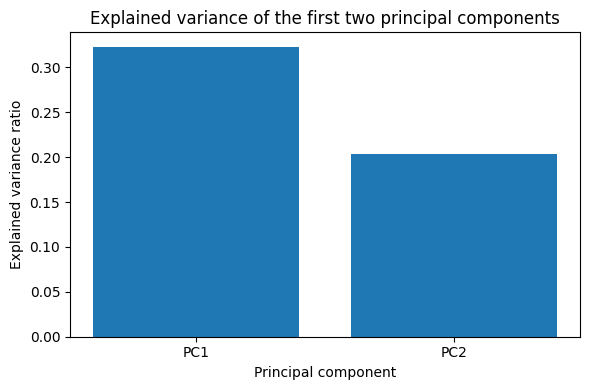

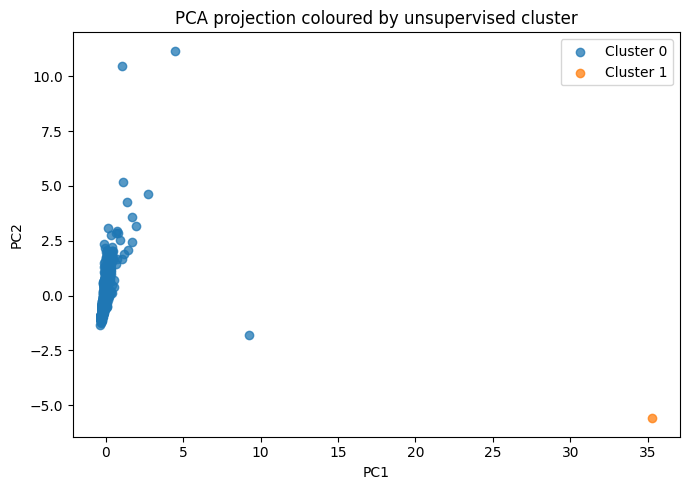

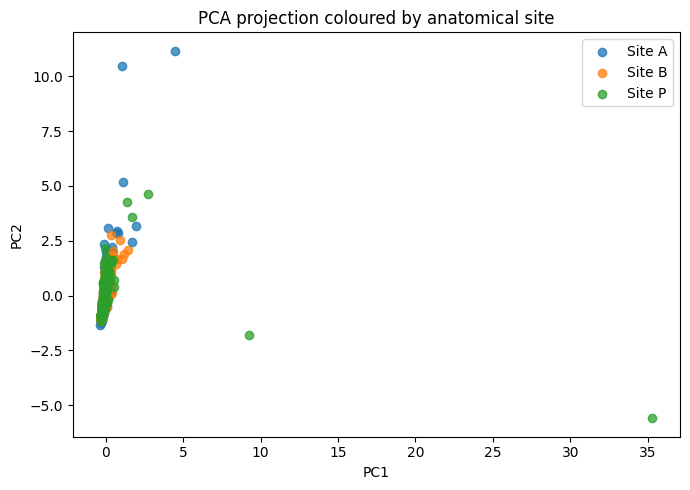

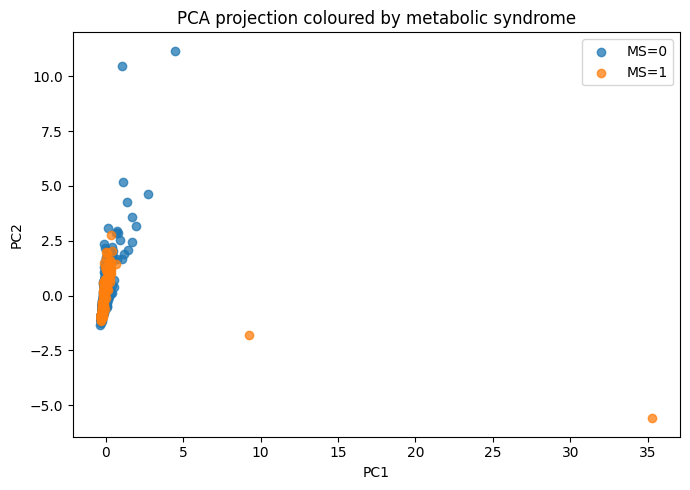


PCA explained variance


,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.322802,0.322802
1,PC2,0.204004,0.526806



PCA loadings


,variable,PC1,PC2
0,c700,0.022981,0.446746
1,visc,0.020014,0.318885
2,c700_sd,0.673715,-0.174254
3,visc_sd,0.676027,-0.169568
4,drift_ratio_median,0.259530,0.470352
5,roughness_ratio_median,0.144260,0.646824



Clustering model selection


...

,cluster,c700_mean,c700_median,visc_mean,visc_median,c700_sd_mean,c700_sd_median,visc_sd_mean,visc_sd_median,drift_ratio_median_mean,drift_ratio_median_median,roughness_ratio_median_mean,roughness_ratio_median_median
0,0,7.277954,6.148287,50.642824,4.037710,5.818580e+03,6.495151e-02,4.522725e+02,3.786925e-01,0.015881,0.008263,0.040895,0.031653
1,1,7.195325,7.195325,3.150289,3.150289,7.269498e+06,7.269498e+06,7.269498e+07,7.269498e+07,0.169893,0.169893,0.073776,0.073776



Cluster composition by anatomical site (%)


site_code,A,B,P
cluster,,,
0,33.43,33.29,33.29
1,0.00,0.00,100.00



Cluster composition by metabolic syndrome (%)


metabolic_syndrome,0,1
cluster,,
0,78.68,21.32
1,0.00,100.00


In [182]:
if len(PCA_CLUSTER_VARS) >= 2 and len(pca_cluster_df) >= 10:
    X = pca_cluster_df[PCA_CLUSTER_VARS].to_numpy(dtype=float)

    # Standardise variables before PCA and clustering
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Reduce the space to 2 principal components for visualisation
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    pca_cluster_df["PC1"] = X_pca[:, 0]
    pca_cluster_df["PC2"] = X_pca[:, 1]

    pca_variance_df = pd.DataFrame({
        "component": ["PC1", "PC2"],
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
    })

    pca_loading_df = pd.DataFrame(
        pca.components_.T,
        index=PCA_CLUSTER_VARS,
        columns=["PC1", "PC2"],
    ).reset_index().rename(columns={"index": "variable"})

    # Select a small number of candidate cluster counts
    candidate_k_list = [2, 3, 4]
    candidate_k_list = [k for k in candidate_k_list if k < len(pca_cluster_df)]

    clustering_selection_rows = []

    for k in candidate_k_list:
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = km.fit_predict(X_scaled)
        silhouette = silhouette_score(X_scaled, labels)

        clustering_selection_rows.append({
            "k": k,
            "silhouette_score": silhouette,
        })

    clustering_selection_df = (
        pd.DataFrame(clustering_selection_rows)
        .sort_values("silhouette_score", ascending=False)
        .reset_index(drop=True)
    )

    best_k = int(clustering_selection_df.loc[0, "k"])
    print("Selected number of clusters:", best_k)

    # Fit the final clustering model
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
    pca_cluster_df["cluster"] = kmeans.fit_predict(X_scaled).astype(int)

    cluster_size_df = (
        pca_cluster_df["cluster"]
        .value_counts(dropna=False)
        .rename_axis("cluster")
        .reset_index(name="n_units")
        .sort_values("cluster")
        .reset_index(drop=True)
    )

    cluster_profile_df = (
        pca_cluster_df
        .groupby("cluster")[PCA_CLUSTER_VARS]
        .agg(["mean", "median"])
        .reset_index()
    )
    cluster_profile_df.columns = [
        "cluster" if col == ("cluster", "") else f"{col[0]}_{col[1]}"
        for col in cluster_profile_df.columns
    ]

    cluster_vs_site_df = pd.DataFrame()
    if "site_code" in pca_cluster_df.columns:
        cluster_vs_site_df = pd.crosstab(
            pca_cluster_df["cluster"],
            pca_cluster_df["site_code"],
            normalize="index",
        ) * 100
        cluster_vs_site_df = cluster_vs_site_df.round(2)

    cluster_vs_ms_df = pd.DataFrame()
    if "metabolic_syndrome" in pca_cluster_df.columns:
        cluster_vs_ms_df = pd.crosstab(
            pca_cluster_df["cluster"],
            pca_cluster_df["metabolic_syndrome"],
            normalize="index",
        ) * 100
        cluster_vs_ms_df = cluster_vs_ms_df.round(2)

    # PCA explained variance
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(pca_variance_df["component"], pca_variance_df["explained_variance_ratio"])
    ax.set_title("Explained variance of the first two principal components")
    ax.set_xlabel("Principal component")
    ax.set_ylabel("Explained variance ratio")
    plt.tight_layout()
    plt.show()

    # PCA coloured by cluster
    fig, ax = plt.subplots(figsize=(7, 5))
    for cluster_id in sorted(pca_cluster_df["cluster"].unique()):
        subset_df = pca_cluster_df.loc[pca_cluster_df["cluster"] == cluster_id]
        ax.scatter(
            subset_df["PC1"],
            subset_df["PC2"],
            label=f"Cluster {cluster_id}",
            alpha=0.75,
        )
    ax.set_title("PCA projection coloured by unsupervised cluster")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # PCA coloured by anatomical site
    if "site_code" in pca_cluster_df.columns:
        fig, ax = plt.subplots(figsize=(7, 5))
        for site_code in sorted(pca_cluster_df["site_code"].dropna().unique()):
            subset_df = pca_cluster_df.loc[pca_cluster_df["site_code"] == site_code]
            ax.scatter(
                subset_df["PC1"],
                subset_df["PC2"],
                label=f"Site {site_code}",
                alpha=0.75,
            )
        ax.set_title("PCA projection coloured by anatomical site")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.legend()
        plt.tight_layout()
        plt.show()

    # PCA coloured by metabolic syndrome
    if "metabolic_syndrome" in pca_cluster_df.columns:
        fig, ax = plt.subplots(figsize=(7, 5))
        for ms_value in sorted(pca_cluster_df["metabolic_syndrome"].dropna().unique()):
            subset_df = pca_cluster_df.loc[pca_cluster_df["metabolic_syndrome"] == ms_value]
            ax.scatter(
                subset_df["PC1"],
                subset_df["PC2"],
                label=f"MS={int(ms_value)}",
                alpha=0.75,
            )
        ax.set_title("PCA projection coloured by metabolic syndrome")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.legend()
        plt.tight_layout()
        plt.show()

    print("\nPCA explained variance")
    display(pca_variance_df)

    print("\nPCA loadings")
    display(pca_loading_df)

    print("\nClustering model selection")
    display(clustering_selection_df)

    print("\nCluster sizes")
    display(cluster_size_df)

    print("\nCluster profiles")
    display(cluster_profile_df)

    if not cluster_vs_site_df.empty:
        print("\nCluster composition by anatomical site (%)")
        display(cluster_vs_site_df)

    if not cluster_vs_ms_df.empty:
        print("\nCluster composition by metabolic syndrome (%)")
        display(cluster_vs_ms_df)

else:
    print("\nPCA/clustering not run because there were not enough complete observations or variables.")

## 4.6. Robust retry of PCA + clustering

In [183]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import chi2_contingency

### 4.6.1. Rebuild the PCA input table

In [184]:
PCA_CLUSTER_VARS = [
    "c700",
    "visc",
    "c700_sd",
    "visc_sd",
    "drift_ratio_median",
    "roughness_ratio_median",
]
PCA_CLUSTER_VARS = [c for c in PCA_CLUSTER_VARS if c in stat_work_df.columns]

# Keep the PCA variables together with the cardiometabolic flags
# that define metabolic syndrome, so they can be explored afterwards.
cluster_risk_flag_vars = [
    "metabolic_syndrome",
    "abdominal_obesity",
    "high_triglycerides",
    "low_hdl",
    "hypertension",
    "high_glucose",
]
cluster_risk_flag_vars = [c for c in cluster_risk_flag_vars if c in stat_work_df.columns]

pca_retry_df = stat_work_df[
    ["analysis_unit_id", "site_code", "protocol_version"]
    + cluster_risk_flag_vars
    + PCA_CLUSTER_VARS
].dropna(subset=PCA_CLUSTER_VARS).copy()

print("Rows available for PCA retry:", len(pca_retry_df))
print("Variables used:", PCA_CLUSTER_VARS)

Rows available for PCA retry: 728
Variables used: ['c700', 'visc', 'c700_sd', 'visc_sd', 'drift_ratio_median', 'roughness_ratio_median']


### 4.6.2. Inspect the most extreme rows in the problematic SD variables

In [185]:
sd_vars = [c for c in ["c700_sd", "visc_sd"] if c in pca_retry_df.columns]

if len(sd_vars) > 0:
    print("\nMost extreme rows in SD-like physical variables")
    display(
        pca_retry_df
        .sort_values(sd_vars, ascending=False)
        [["analysis_unit_id", "site_code", "protocol_version"] + [c for c in ["metabolic_syndrome"] if c in pca_retry_df.columns] + sd_vars]
        .head(10)
    )


Most extreme rows in SD-like physical variables


,analysis_unit_id,site_code,protocol_version,metabolic_syndrome,c700_sd,visc_sd
595,unit_000595,P,new,1,7.269498e+06,7.269498e+07
673,unit_000673,P,new,1,4.229974e+06,6.553500e+04
666,unit_000666,B,new,0,1.296013e+01,3.286096e+04
711,unit_000711,B,new,1,1.234908e+01,1.204406e+02
720,unit_000720,B,new,1,4.375930e+00,8.039184e+01
694,unit_000694,P,new,0,1.938764e+00,1.437470e+01
645,unit_000645,B,new,0,1.873809e+00,1.427116e+01
693,unit_000693,B,new,0,1.415223e+00,6.845379e+00
670,unit_000670,P,new,0,1.378524e+00,3.277439e+04
695,unit_000695,A,new,0,1.069312e+00,8.781973e+00


### 4.6.3. Apply a simple robust outlier filter

In [186]:
#    Rule:
#    remove rows above Q3 + 5*IQR in any SD variable

pca_retry_clean_df = pca_retry_df.copy()

if len(sd_vars) > 0:
    keep_mask = pd.Series(True, index=pca_retry_clean_df.index)

    for col in sd_vars:
        q1 = pca_retry_clean_df[col].quantile(0.25)
        q3 = pca_retry_clean_df[col].quantile(0.75)
        iqr = q3 - q1
        upper_bound = q3 + 5 * iqr

        keep_mask &= (pca_retry_clean_df[col] <= upper_bound)

        print(f"{col}: Q1={q1:.6g}, Q3={q3:.6g}, IQR={iqr:.6g}, upper_bound={upper_bound:.6g}")

    n_removed = int((~keep_mask).sum())
    print("\nRows removed by robust SD-based filter:", n_removed)

    pca_retry_clean_df = pca_retry_clean_df.loc[keep_mask].copy()

print("Rows retained for robust PCA retry:", len(pca_retry_clean_df))

c700_sd: Q1=0.017273, Q3=0.209072, IQR=0.191799, upper_bound=1.16807
visc_sd: Q1=0.0981189, Q3=1.43656, IQR=1.33844, upper_bound=8.12878

Rows removed by robust SD-based filter: 23
Rows retained for robust PCA retry: 705


### 4.6.4. Optional log-transform for very skewed SD variables

In [187]:
#    This helps reduce dominance of extreme scales.
for col in sd_vars:
    pca_retry_clean_df[col] = np.log1p(pca_retry_clean_df[col])

### 4.6.5. Run PCA using more components

In [188]:
X = pca_retry_clean_df[PCA_CLUSTER_VARS].to_numpy(dtype=float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use up to 4 PCs, but never more than the number of variables
n_pcs = min(4, X_scaled.shape[1])
pca_retry = PCA(n_components=n_pcs, random_state=42)
X_pca_retry = pca_retry.fit_transform(X_scaled)

# Store the first two PCs for plotting
pca_retry_clean_df["PC1"] = X_pca_retry[:, 0]
pca_retry_clean_df["PC2"] = X_pca_retry[:, 1]

# Build a table of explained variance
pca_retry_variance_df = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(n_pcs)],
    "explained_variance_ratio": pca_retry.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca_retry.explained_variance_ratio_),
})

print("\nExplained variance in robust PCA retry")
display(pca_retry_variance_df)


Explained variance in robust PCA retry


,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.449944,0.449944
1,PC2,0.185611,0.635556
2,PC3,0.139736,0.775292
3,PC4,0.115305,0.890597


### 4.6.6. Cluster on the retained PCA space

In [189]:
candidate_k_list = [2, 3, 4, 5]
candidate_k_list = [k for k in candidate_k_list if k < len(pca_retry_clean_df)]

X_cluster = X_pca_retry

clustering_retry_rows = []

for k in candidate_k_list:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_cluster)
    sil = silhouette_score(X_cluster, labels)

    clustering_retry_rows.append({
        "k": k,
        "silhouette_score": sil,
    })

clustering_retry_selection_df = (
    pd.DataFrame(clustering_retry_rows)
    .sort_values("silhouette_score", ascending=False)
    .reset_index(drop=True)
)

print("\nRobust clustering model selection")
display(clustering_retry_selection_df)


Robust clustering model selection


,k,silhouette_score
0,3,0.505102
1,2,0.491563
2,5,0.483711
3,4,0.460926


In [190]:
best_k_retry = int(clustering_retry_selection_df.loc[0, "k"])
print("Selected number of clusters after robust retry:", best_k_retry)

Selected number of clusters after robust retry: 3


In [191]:
kmeans_retry = KMeans(n_clusters=best_k_retry, random_state=42, n_init=20)
pca_retry_clean_df["cluster"] = kmeans_retry.fit_predict(X_cluster).astype(int)

cluster_retry_size_df = (
    pca_retry_clean_df["cluster"]
    .value_counts(dropna=False)
    .rename_axis("cluster")
    .reset_index(name="n_units")
    .sort_values("cluster")
    .reset_index(drop=True)
)

print("\nCluster sizes after robust retry")
display(cluster_retry_size_df)


Cluster sizes after robust retry


,cluster,n_units
0,0,219
1,1,476
2,2,10


### 4.6.7. Cluster profiles

In [192]:
cluster_retry_profile_df = (
    pca_retry_clean_df
    .groupby("cluster")[PCA_CLUSTER_VARS]
    .agg(["mean", "median"])
    .reset_index()
)

cluster_retry_profile_df.columns = [
    "cluster" if col == ("cluster", "") else f"{col[0]}_{col[1]}"
    for col in cluster_retry_profile_df.columns
]

print("\nCluster profiles after robust retry")
display(cluster_retry_profile_df)


Cluster profiles after robust retry


,cluster,c700_mean,c700_median,visc_mean,visc_median,c700_sd_mean,c700_sd_median,visc_sd_mean,visc_sd_median,drift_ratio_median_mean,drift_ratio_median_median,roughness_ratio_median_mean,roughness_ratio_median_median
0,0,9.547140,8.166843,8.736036,6.965866,0.264045,0.251782,1.148728,1.129035,0.015883,0.010827,0.054633,0.050185
1,1,6.118315,5.628616,3.822550,3.542912,0.041404,0.024542,0.214554,0.133239,0.010737,0.006825,0.033621,0.027326
2,2,8.981269,6.206886,6.089250,5.184060,0.083715,0.057636,0.370772,0.285037,0.256449,0.228805,0.058486,0.024105


### 4.6.8. Composition by site and cardiometabolic flags

In [193]:
# Composition by anatomical site
cluster_retry_vs_site_df = pd.DataFrame()

if "site_code" in pca_retry_clean_df.columns:
    cluster_retry_vs_site_df = pd.crosstab(
        pca_retry_clean_df["cluster"],
        pca_retry_clean_df["site_code"],
        normalize="index",
    ) * 100
    cluster_retry_vs_site_df = cluster_retry_vs_site_df.round(2)

if not cluster_retry_vs_site_df.empty:
    print("\nCluster composition by anatomical site (%)")
    display(cluster_retry_vs_site_df)


Cluster composition by anatomical site (%)


site_code,A,B,P
cluster,,,
0,35.16,30.59,34.25
1,32.35,34.24,33.40
2,40.00,30.00,30.00


In [194]:
# Composition by cardiometabolic flags
cluster_retry_flag_tables = {}
cluster_retry_flag_count_tables = {}

cluster_flag_vars = [
    "metabolic_syndrome",
    "abdominal_obesity",
    "high_triglycerides",
    "low_hdl",
    "hypertension",
    "high_glucose",
]
cluster_flag_vars = [c for c in cluster_flag_vars if c in pca_retry_clean_df.columns]

for flag_var in cluster_flag_vars:
    tmp = pca_retry_clean_df.loc[
        pca_retry_clean_df[flag_var].notna(),
        ["cluster", flag_var]
    ].copy()

    if tmp.empty:
        continue

    count_table = pd.crosstab(
        tmp["cluster"],
        tmp[flag_var],
    )

    pct_table = pd.crosstab(
        tmp["cluster"],
        tmp[flag_var],
        normalize="index",
    ) * 100

    cluster_retry_flag_count_tables[flag_var] = count_table
    cluster_retry_flag_tables[flag_var] = pct_table.round(2)

print("\nCluster composition by cardiometabolic flags (%)")
for flag_var, flag_table in cluster_retry_flag_tables.items():
    print(f"\n{flag_var}")
    display(flag_table)


Cluster composition by cardiometabolic flags (%)

metabolic_syndrome


metabolic_syndrome,0,1
cluster,,
0,76.71,23.29
1,79.20,20.80
2,100.00,0.00



abdominal_obesity


abdominal_obesity,0,1
cluster,,
0,21.00,79.00
1,21.01,78.99
2,40.00,60.00



high_triglycerides


...

low_hdl,0,1
cluster,,
0,73.52,26.48
1,75.00,25.00
2,100.00,0.00



hypertension


hypertension,0,1
cluster,,
0,69.86,30.14
1,66.39,33.61
2,90.00,10.00



high_glucose


high_glucose,0,1
cluster,,
0,86.76,13.24
1,84.45,15.55
2,80.00,20.00


### 4.6.9. Formal association tests: cluster vs cardiometabolic flags

In [195]:
cluster_flag_test_rows = []

for flag_var in cluster_flag_vars:
    count_table = cluster_retry_flag_count_tables.get(flag_var)

    if count_table is None or count_table.empty:
        continue

    chi2_statistic, p_value, dof, expected = chi2_contingency(count_table)

    cluster_flag_test_rows.append({
        "flag_variable": flag_var,
        "n_total": int(count_table.to_numpy().sum()),
        "chi2_statistic": float(chi2_statistic),
        "degrees_of_freedom": int(dof),
        "p_value": float(p_value),
        "min_expected_count": float(expected.min()),
        "any_expected_below_5": bool((expected < 5).any()),
    })

cluster_flag_test_df = pd.DataFrame(cluster_flag_test_rows)

if not cluster_flag_test_df.empty:
    cluster_flag_test_df["p_fdr"] = multipletests(
        cluster_flag_test_df["p_value"].values,
        method="fdr_bh",
    )[1]
    cluster_flag_test_df["significant_fdr_05"] = (
        cluster_flag_test_df["p_fdr"] < 0.05
    )

    cluster_flag_test_df = cluster_flag_test_df.sort_values(
        ["p_fdr", "p_value", "flag_variable"]
    ).reset_index(drop=True)

print("\nFormal association tests: cluster vs cardiometabolic flags")
display(cluster_flag_test_df)


Formal association tests: cluster vs cardiometabolic flags


,flag_variable,n_total,chi2_statistic,degrees_of_freedom,p_value,min_expected_count,any_expected_below_5,p_fdr,significant_fdr_05
0,low_hdl,705,3.576184,2,0.167279,2.510638,True,0.420259,False
1,metabolic_syndrome,705,3.296514,2,0.192385,2.127660,True,0.420259,False
2,hypertension,705,3.120061,2,0.210130,3.219858,True,0.420259,False
3,abdominal_obesity,705,2.123089,2,0.345921,2.127660,True,0.518882,False
4,high_glucose,705,0.836946,2,0.658051,1.489362,True,0.789661,False
5,high_triglycerides,705,0.352779,2,0.838291,1.631206,True,0.838291,False


In [196]:
print("\nContingency tables by cardiometabolic flag")
for flag_var in cluster_flag_vars:
    if flag_var not in cluster_retry_flag_count_tables:
        continue

    print(f"\n{flag_var} - counts")
    display(cluster_retry_flag_count_tables[flag_var])

    print(f"{flag_var} - row percentages (%)")
    display(cluster_retry_flag_tables[flag_var])


Contingency tables by cardiometabolic flag

metabolic_syndrome - counts


metabolic_syndrome,0,1
cluster,,
0,168,51
1,377,99
2,10,0


metabolic_syndrome - row percentages (%)


metabolic_syndrome,0,1
cluster,,
0,76.71,23.29
1,79.20,20.80
2,100.00,0.00



abdominal_obesity - counts


...

hypertension,0,1
cluster,,
0,69.86,30.14
1,66.39,33.61
2,90.00,10.00



high_glucose - counts


high_glucose,0,1
cluster,,
0,190,29
1,402,74
2,8,2


high_glucose - row percentages (%)


high_glucose,0,1
cluster,,
0,86.76,13.24
1,84.45,15.55
2,80.00,20.00


### 4.6.10. Visualisations

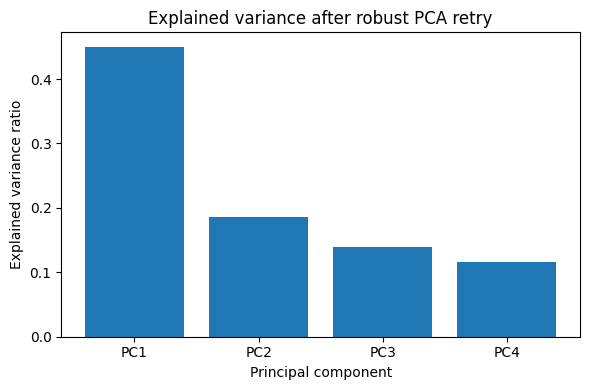

In [197]:
# Explained variance of the retained principal components
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    pca_retry_variance_df["component"],
    pca_retry_variance_df["explained_variance_ratio"]
)
ax.set_title("Explained variance after robust PCA retry")
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
plt.tight_layout()
plt.show()

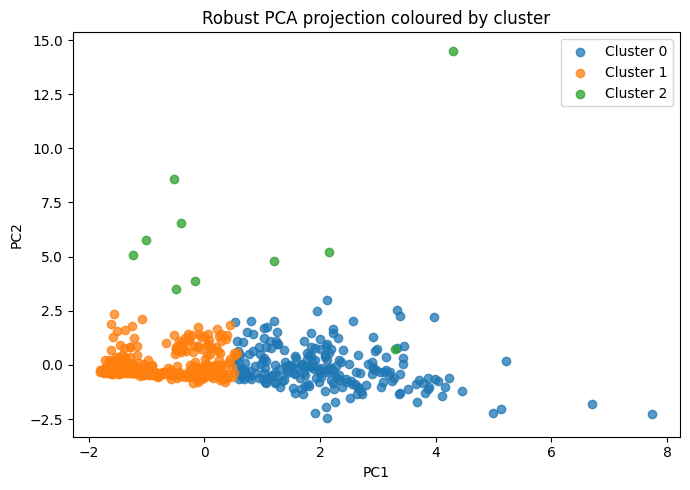

In [198]:
# PCA projection coloured by cluster
fig, ax = plt.subplots(figsize=(7, 5))
for cluster_id in sorted(pca_retry_clean_df["cluster"].unique()):
    subset_df = pca_retry_clean_df.loc[pca_retry_clean_df["cluster"] == cluster_id]
    ax.scatter(
        subset_df["PC1"],
        subset_df["PC2"],
        alpha=0.75,
        label=f"Cluster {cluster_id}",
    )
ax.set_title("Robust PCA projection coloured by cluster")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.show()

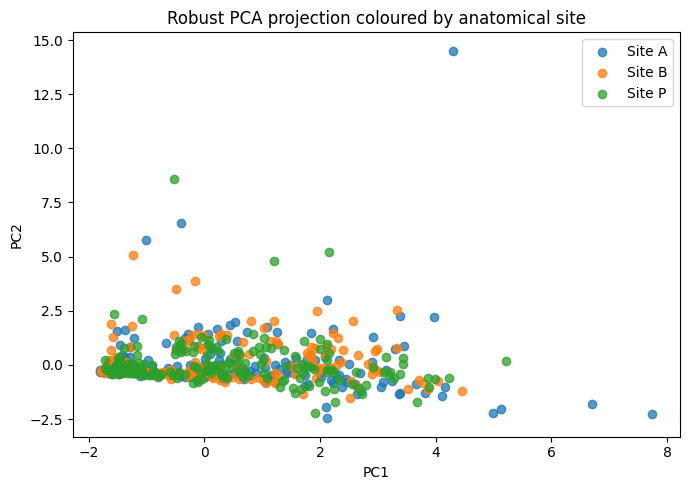

In [199]:
# PCA projection coloured by anatomical site
if "site_code" in pca_retry_clean_df.columns:
    fig, ax = plt.subplots(figsize=(7, 5))
    for site_code in sorted(pca_retry_clean_df["site_code"].dropna().unique()):
        subset_df = pca_retry_clean_df.loc[pca_retry_clean_df["site_code"] == site_code]
        ax.scatter(
            subset_df["PC1"],
            subset_df["PC2"],
            alpha=0.75,
            label=f"Site {site_code}",
        )
    ax.set_title("Robust PCA projection coloured by anatomical site")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    plt.tight_layout()
    plt.show()

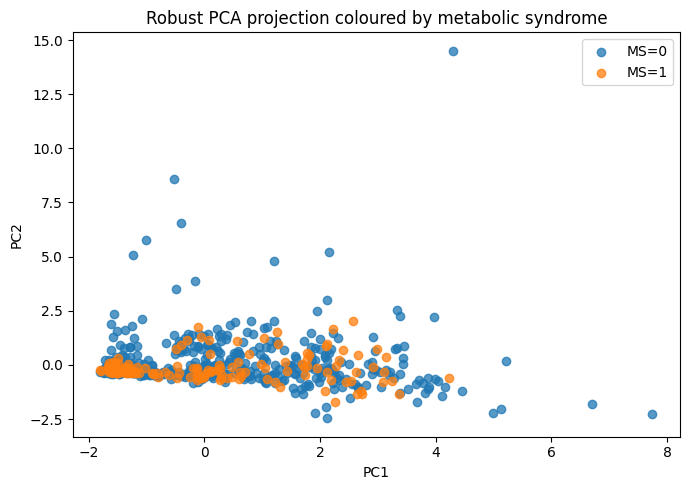

In [200]:
# PCA projection coloured by metabolic syndrome
if "metabolic_syndrome" in pca_retry_clean_df.columns:
    fig, ax = plt.subplots(figsize=(7, 5))
    for ms_value in sorted(pca_retry_clean_df["metabolic_syndrome"].dropna().unique()):
        subset_df = pca_retry_clean_df.loc[pca_retry_clean_df["metabolic_syndrome"] == ms_value]
        ax.scatter(
            subset_df["PC1"],
            subset_df["PC2"],
            alpha=0.75,
            label=f"MS={int(ms_value)}",
        )
    ax.set_title("Robust PCA projection coloured by metabolic syndrome")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 4.7. Extra exploratory tests: cluster vs sex / protocol / number of cardiometabolic components

In [201]:
# Add extra variables to the PCA-clean table if needed
extra_cols = [
    "analysis_unit_id",
    "Sex",
    "abdominal_obesity",
    "high_triglycerides",
    "low_hdl",
    "hypertension",
    "high_glucose",
]
extra_cols = [c for c in extra_cols if c in stat_work_df.columns]


In [202]:
# Start from the PCA-clean table
pca_retry_test_df = pca_retry_clean_df.copy()

In [203]:
# Add only missing columns from stat_work_df to avoid duplicated _x / _y columns
missing_extra_cols = [
    c for c in extra_cols
    if c != "analysis_unit_id" and c not in pca_retry_test_df.columns
]

if len(missing_extra_cols) > 0:
    pca_retry_test_df = pca_retry_test_df.merge(
        stat_work_df[["analysis_unit_id"] + missing_extra_cols].drop_duplicates(subset=["analysis_unit_id"]),
        on="analysis_unit_id",
        how="left",
    )

In [204]:
# Build number of positive cardiometabolic components
risk_component_cols = [
    "abdominal_obesity",
    "high_triglycerides",
    "low_hdl",
    "hypertension",
    "high_glucose",
]
risk_component_cols = [c for c in risk_component_cols if c in pca_retry_test_df.columns]

for col in risk_component_cols:
    pca_retry_test_df[col] = pd.to_numeric(pca_retry_test_df[col], errors="coerce")

pca_retry_test_df["n_ms_components"] = (
    pca_retry_test_df[risk_component_cols]
    .fillna(0)
    .astype(float)
    .sum(axis=1)
)

In [205]:
# Simple sex harmonisation
if "Sex" in pca_retry_test_df.columns:
    sex_num = pd.to_numeric(pca_retry_test_df["Sex"], errors="coerce")

    if sex_num.notna().any():
        pca_retry_test_df["sex_binary"] = sex_num.astype("Int64")
    else:
        sex_map = {
            "H": 0, "HOMBRE": 0, "MALE": 0, "MASCULINO": 0, "MASC": 0,
            "M": 1, "MUJER": 1, "FEMALE": 1, "FEMENINO": 1, "FEM": 1,
        }
        pca_retry_test_df["sex_binary"] = (
            pca_retry_test_df["Sex"].astype(str).str.strip().str.upper().map(sex_map)
        )
        pca_retry_test_df["sex_binary"] = pd.to_numeric(
            pca_retry_test_df["sex_binary"], errors="coerce"
        ).astype("Int64")

In [206]:
# Helper for chi-square tests
def _chi2_test_from_crosstab(df, row_var, col_var):
    tmp = df.loc[df[row_var].notna() & df[col_var].notna(), [row_var, col_var]].copy()

    if tmp.empty:
        return None, None

    table = pd.crosstab(tmp[row_var], tmp[col_var])

    if table.shape[0] < 2 or table.shape[1] < 2:
        return table, None

    chi2_stat, p_value, dof, expected = chi2_contingency(table)

    result = {
        "variable": col_var,
        "n_total": int(table.to_numpy().sum()),
        "chi2_statistic": float(chi2_stat),
        "degrees_of_freedom": int(dof),
        "p_value": float(p_value),
        "min_expected_count": float(expected.min()),
        "any_expected_below_5": bool((expected < 5).any()),
    }

    return table, result

In [207]:
# Run tests
test_specs = []

if "sex_binary" in pca_retry_test_df.columns:
    test_specs.append("sex_binary")

if "protocol_version" in pca_retry_test_df.columns:
    test_specs.append("protocol_version")

if "n_ms_components" in pca_retry_test_df.columns:
    test_specs.append("n_ms_components")

association_tables = {}
association_rows = []

for var in test_specs:
    table, result = _chi2_test_from_crosstab(
        pca_retry_test_df,
        row_var="cluster",
        col_var=var,
    )

    if table is not None:
        association_tables[var] = table

    if result is not None:
        association_rows.append(result)

association_test_df = pd.DataFrame(association_rows)

if not association_test_df.empty:
    association_test_df["p_fdr"] = multipletests(
        association_test_df["p_value"].values,
        method="fdr_bh",
    )[1]
    association_test_df["significant_fdr_05"] = association_test_df["p_fdr"] < 0.05
    association_test_df = association_test_df.sort_values(
        ["p_fdr", "p_value", "variable"]
    ).reset_index(drop=True)

print("\nAssociation tests: cluster vs sex / protocol / n_ms_components")
display(association_test_df)

for var, table in association_tables.items():
    print(f"\nContingency table: cluster vs {var}")
    display(table)



Association tests: cluster vs sex / protocol / n_ms_components


,variable,n_total,chi2_statistic,degrees_of_freedom,p_value,min_expected_count,any_expected_below_5,p_fdr,significant_fdr_05
0,protocol_version,705,269.075878,2,3.723193e-59,3.333333,True,1.116958e-58,True
1,sex_binary,705,5.978785,2,5.031798e-02,4.978723,True,7.547698e-02,False
2,n_ms_components,705,13.841338,8,8.599578e-02,0.468085,True,8.599578e-02,False



Contingency table: cluster vs sex_binary


sex_binary,0,1
cluster,,
0,124,95
1,222,254
2,5,5



Contingency table: cluster vs protocol_version


protocol_version,new,old
cluster,,
0,168,51
1,66,410
2,1,9



Contingency table: cluster vs n_ms_components


n_ms_components,0.0,1.0,2.0,3.0,4.0
cluster,,,,,
0,32,68,68,45,6
1,64,144,169,72,27
2,4,2,4,0,0


In [208]:
# Simple descriptive summary of number of components by cluster
print("\nNumber of positive cardiometabolic components by cluster")
display(
    pca_retry_test_df.groupby("cluster")["n_ms_components"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)


Number of positive cardiometabolic components by cluster


,cluster,count,mean,median,min,max
0,0,219,1.657534,2.0,0.0,4.0
1,1,476,1.693277,2.0,0.0,4.0
2,2,10,1.000000,1.0,0.0,2.0


In [209]:
# Quick sanity check
print("\nSanity check for n_ms_components")
display(
    pca_retry_test_df[
        ["analysis_unit_id", "cluster"] + risk_component_cols + ["n_ms_components"]
    ].head(10)
)


Sanity check for n_ms_components


,analysis_unit_id,cluster,abdominal_obesity,high_triglycerides,low_hdl,hypertension,high_glucose,n_ms_components
0,unit_000000,1,1,0,0,0,0,1.0
1,unit_000001,1,1,0,0,0,0,1.0
2,unit_000002,1,1,0,0,0,0,1.0
3,unit_000003,1,1,0,0,0,0,1.0
4,unit_000004,2,1,0,0,0,0,1.0
5,unit_000005,1,1,0,0,0,0,1.0
6,unit_000006,1,1,0,0,0,0,1.0
7,unit_000007,1,1,0,0,0,0,1.0
8,unit_000008,1,1,0,0,0,0,1.0
9,unit_000009,1,0,0,0,0,0,0.0


### 4.7.1. Optional compact visualisations

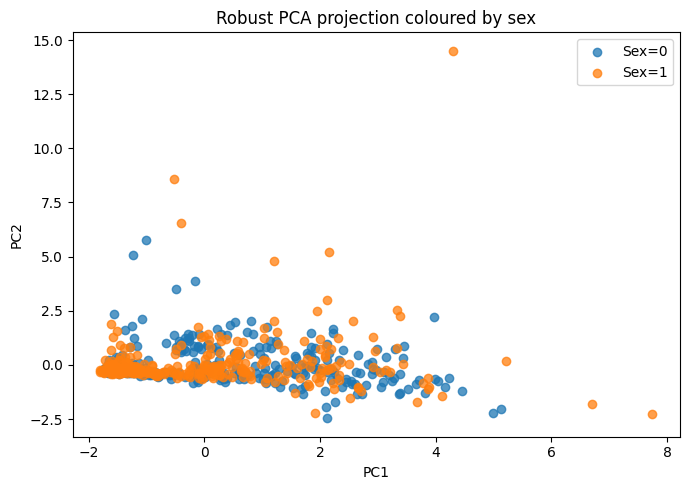

In [210]:
# PCA coloured by sex
if "sex_binary" in pca_retry_test_df.columns:
    fig, ax = plt.subplots(figsize=(7, 5))
    for sex_value in sorted(pca_retry_test_df["sex_binary"].dropna().unique()):
        subset_df = pca_retry_test_df.loc[pca_retry_test_df["sex_binary"] == sex_value]
        ax.scatter(
            subset_df["PC1"],
            subset_df["PC2"],
            alpha=0.75,
            label=f"Sex={int(sex_value)}",
        )
    ax.set_title("Robust PCA projection coloured by sex")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    plt.tight_layout()
    plt.show()

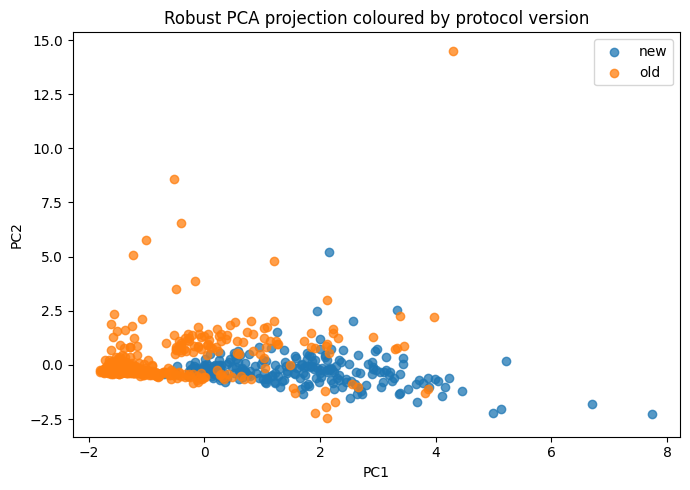

In [211]:
# PCA coloured by protocol
if "protocol_version" in pca_retry_test_df.columns:
    fig, ax = plt.subplots(figsize=(7, 5))
    for protocol_value in sorted(pca_retry_test_df["protocol_version"].dropna().unique()):
        subset_df = pca_retry_test_df.loc[pca_retry_test_df["protocol_version"] == protocol_value]
        ax.scatter(
            subset_df["PC1"],
            subset_df["PC2"],
            alpha=0.75,
            label=f"{protocol_value}",
        )
    ax.set_title("Robust PCA projection coloured by protocol version")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 4.8. Protocol-stratified exploratory analysis and simple supervised modelling

This section follows the previous unsupervised analysis, where protocol_version appeared to be the dominant source of latent structure. For that reason:
 1) PCA is repeated separately within each protocol
 2) a simple supervised model is evaluated within each protocol


In [212]:
# New imports needed only for the supervised step
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

### 4.8.1. Configuration

In [213]:
protocol_analysis_df = stat_work_df.copy()

PROTOCOL_LIST = sorted(protocol_analysis_df["protocol_version"].dropna().unique())

In [214]:
# Variables for protocol-specific PCA
PCA_PROTOCOL_VARS = [
    "c700",
    "visc",
    "c700_sd",
    "visc_sd",
    "drift_ratio_median",
    "roughness_ratio_median",
]
PCA_PROTOCOL_VARS = [c for c in PCA_PROTOCOL_VARS if c in protocol_analysis_df.columns]

In [215]:
# Variables for simple supervised modelling
MODEL_FEATURES = [
    "c700",
    "visc",
    "c700_sd",
    "visc_sd",
    "p2p_median",
    "rms_median",
    "drift_ratio_median",
    "roughness_ratio_median",
]
MODEL_FEATURES = [c for c in MODEL_FEATURES if c in protocol_analysis_df.columns]

MODEL_TARGETS = [
    "metabolic_syndrome",
    "high_glucose",
]
MODEL_TARGETS = [c for c in MODEL_TARGETS if c in protocol_analysis_df.columns]

### 4.8.2. PCA repeated separately within each protocol

In [216]:
def _run_protocol_pca(df, feature_cols):
    """
    Run PCA within one protocol and return:
    - projected dataframe
    - explained variance table
    - loadings table
    """
    keep_cols = ["analysis_unit_id", "protocol_version", "site_code"]
    keep_cols += [c for c in ["metabolic_syndrome"] if c in df.columns]
    keep_cols += feature_cols

    tmp = df[keep_cols].dropna(subset=feature_cols).copy()

    if len(tmp) < 10 or len(feature_cols) < 2:
        return None, None, None

    X = tmp[feature_cols].to_numpy(dtype=float)
    X_scaled = StandardScaler().fit_transform(X)

    n_pcs = min(4, X_scaled.shape[0], X_scaled.shape[1])
    if n_pcs < 2:
        return None, None, None

    pca = PCA(n_components=n_pcs, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    for i in range(n_pcs):
        tmp[f"PC{i+1}"] = X_pca[:, i]

    variance_df = pd.DataFrame({
        "component": [f"PC{i+1}" for i in range(n_pcs)],
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
    })

    loadings_df = pd.DataFrame(
        pca.components_.T,
        index=feature_cols,
        columns=[f"PC{i+1}" for i in range(n_pcs)],
    ).reset_index().rename(columns={"index": "variable"})

    return tmp, variance_df, loadings_df



Protocol-specific PCA: new

Explained variance


,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.390396,0.390396
1,PC2,0.194797,0.585193
2,PC3,0.172285,0.757478
3,PC4,0.149967,0.907445



PCA loadings


,variable,PC1,PC2,PC3,PC4
0,c700,-0.090011,0.025302,0.888461,-0.407137
1,visc,0.066544,0.575558,0.352938,0.717448
2,c700_sd,0.558234,-0.356531,0.153851,0.120866
3,visc_sd,0.569280,-0.337697,0.153582,0.111121
4,drift_ratio_median,0.493345,0.353307,-0.161913,-0.078988
5,roughness_ratio_median,0.329205,0.549649,-0.112244,-0.535081


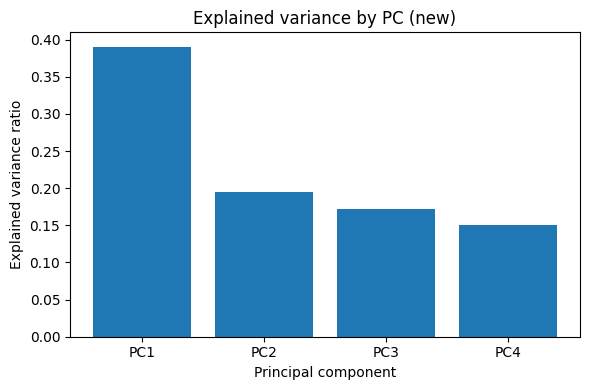

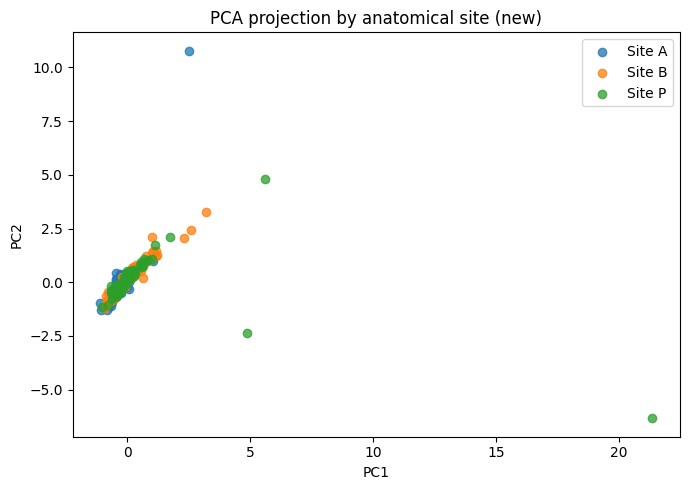

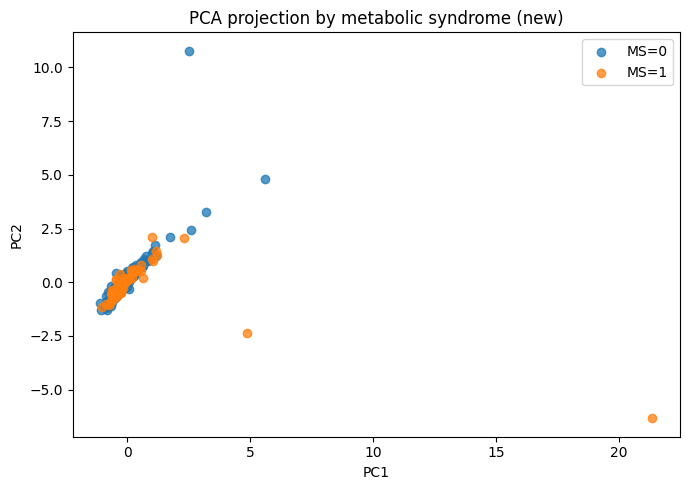


Protocol-specific PCA: old

Explained variance


,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.473210,0.473210
1,PC2,0.178252,0.651462
2,PC3,0.159084,0.810547
3,PC4,0.100105,0.910652



PCA loadings


,variable,PC1,PC2,PC3,PC4
0,c700,0.285692,-0.377149,0.693784,0.051933
1,visc,0.423446,-0.169057,0.206282,0.559732
2,c700_sd,0.552626,-0.050459,-0.199329,-0.385064
3,visc_sd,0.550669,-0.047621,-0.208379,-0.392114
4,drift_ratio_median,0.085175,0.772088,0.547307,-0.250917
5,roughness_ratio_median,0.350981,0.477750,-0.305635,0.564815


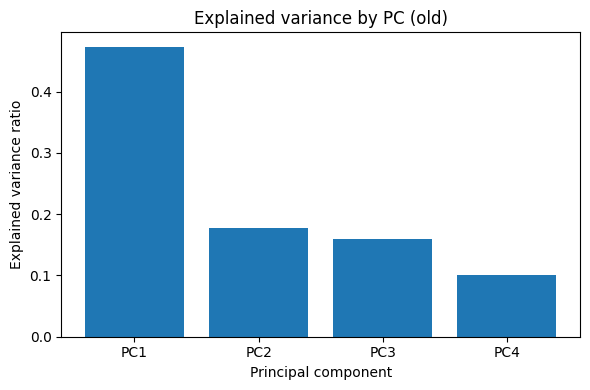

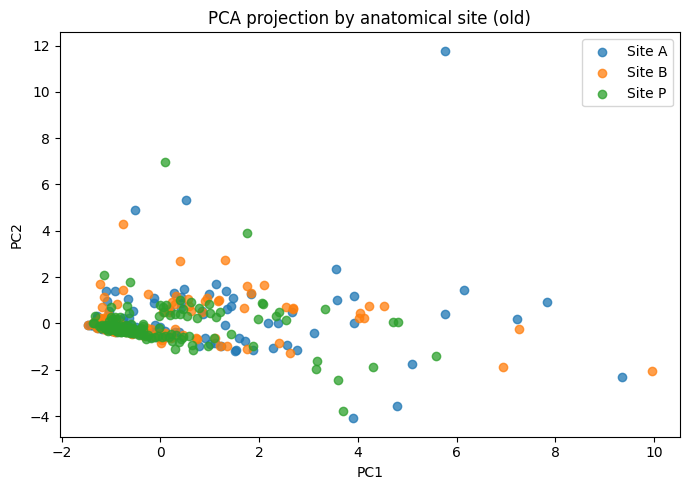

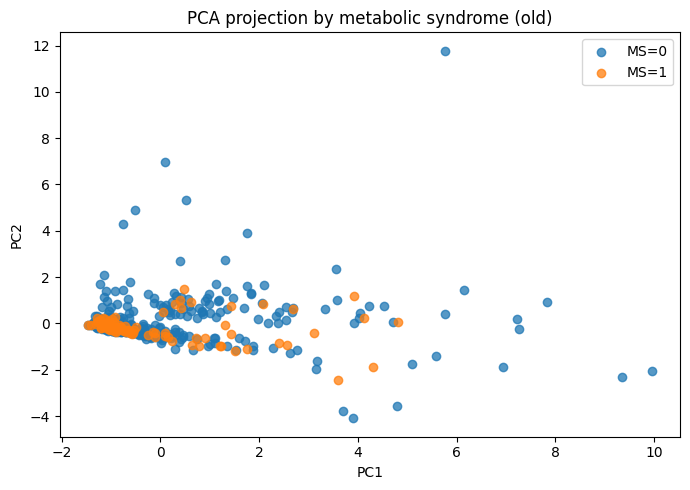

In [217]:
protocol_pca_tables = {}
protocol_pca_variance_tables = {}
protocol_pca_loading_tables = {}

for protocol_value in PROTOCOL_LIST:
    print("\n" + "=" * 60)
    print(f"Protocol-specific PCA: {protocol_value}")
    print("=" * 60)

    protocol_df = protocol_analysis_df.loc[
        protocol_analysis_df["protocol_version"] == protocol_value
    ].copy()

    pca_df, variance_df, loadings_df = _run_protocol_pca(
        protocol_df,
        feature_cols=PCA_PROTOCOL_VARS,
    )

    if pca_df is None:
        print("Not enough complete observations to run PCA.")
        continue

    protocol_pca_tables[protocol_value] = pca_df
    protocol_pca_variance_tables[protocol_value] = variance_df
    protocol_pca_loading_tables[protocol_value] = loadings_df

    print("\nExplained variance")
    display(variance_df)

    print("\nPCA loadings")
    display(loadings_df)

    # Plot explained variance
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(
        variance_df["component"],
        variance_df["explained_variance_ratio"]
    )
    ax.set_title(f"Explained variance by PC ({protocol_value})")
    ax.set_xlabel("Principal component")
    ax.set_ylabel("Explained variance ratio")
    plt.tight_layout()
    plt.show()

    # PCA coloured by anatomical site
    if "site_code" in pca_df.columns:
        fig, ax = plt.subplots(figsize=(7, 5))
        for site_code in sorted(pca_df["site_code"].dropna().unique()):
            subset_df = pca_df.loc[pca_df["site_code"] == site_code]
            ax.scatter(
                subset_df["PC1"],
                subset_df["PC2"],
                alpha=0.75,
                label=f"Site {site_code}",
            )
        ax.set_title(f"PCA projection by anatomical site ({protocol_value})")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.legend()
        plt.tight_layout()
        plt.show()

    # PCA coloured by metabolic syndrome
    if "metabolic_syndrome" in pca_df.columns:
        fig, ax = plt.subplots(figsize=(7, 5))
        for ms_value in sorted(pca_df["metabolic_syndrome"].dropna().unique()):
            subset_df = pca_df.loc[pca_df["metabolic_syndrome"] == ms_value]
            ax.scatter(
                subset_df["PC1"],
                subset_df["PC2"],
                alpha=0.75,
                label=f"MS={int(ms_value)}",
            )
        ax.set_title(f"PCA projection by metabolic syndrome ({protocol_value})")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.legend()
        plt.tight_layout()
        plt.show()


### 4.8.3. Simple supervised analysis within each protocol

In [218]:
def _evaluate_protocol_model(df, feature_cols, target_col, protocol_label):
    """
    Evaluate a simple logistic-regression model within one protocol.

    Returns one summary row with cross-validated performance.
    """
    model_df = df[feature_cols + [target_col]].copy()

    for col in feature_cols + [target_col]:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

    model_df = model_df.dropna(subset=feature_cols + [target_col]).copy()

    if model_df.empty:
        return None

    X = model_df[feature_cols].to_numpy(dtype=float)
    y = model_df[target_col].astype(int).to_numpy()

    class_counts = pd.Series(y).value_counts()
    if len(class_counts) < 2:
        return None

    min_class_n = int(class_counts.min())
    if min_class_n < 10 or len(model_df) < 50:
        return None

    n_splits = min(5, min_class_n)
    if n_splits < 3:
        return None

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42,
        )),
    ])

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42,
    )

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "roc_auc": "roc_auc",
            "balanced_accuracy": "balanced_accuracy",
        },
        error_score="raise",
    )

    return {
        "protocol_version": protocol_label,
        "target": target_col,
        "n_units": int(len(model_df)),
        "n_positive": int((y == 1).sum()),
        "positive_prevalence_pct": 100 * float((y == 1).mean()),
        "n_splits": int(n_splits),
        "mean_roc_auc": float(np.mean(scores["test_roc_auc"])),
        "sd_roc_auc": float(np.std(scores["test_roc_auc"])),
        "mean_balanced_accuracy": float(np.mean(scores["test_balanced_accuracy"])),
        "sd_balanced_accuracy": float(np.std(scores["test_balanced_accuracy"])),
    }

In [219]:
supervised_rows = []

for protocol_value in PROTOCOL_LIST:
    protocol_df = protocol_analysis_df.loc[
        protocol_analysis_df["protocol_version"] == protocol_value
    ].copy()

    for target_col in MODEL_TARGETS:
        row = _evaluate_protocol_model(
            protocol_df,
            feature_cols=MODEL_FEATURES,
            target_col=target_col,
            protocol_label=protocol_value,
        )

        if row is not None:
            supervised_rows.append(row)

supervised_protocol_results_df = pd.DataFrame(supervised_rows)

print("\nProtocol-specific supervised results")
display(supervised_protocol_results_df)


Protocol-specific supervised results


,protocol_version,target,n_units,n_positive,positive_prevalence_pct,n_splits,mean_roc_auc,sd_roc_auc,mean_balanced_accuracy,sd_balanced_accuracy
0,new,metabolic_syndrome,258,63,24.418605,5,0.473997,0.067506,0.485256,0.049471
1,new,high_glucose,258,27,10.465116,5,0.634095,0.113994,0.558264,0.081735
2,old,metabolic_syndrome,470,93,19.787234,5,0.558632,0.087733,0.518830,0.061049
3,old,high_glucose,470,80,17.021277,5,0.570192,0.043410,0.550962,0.027128


### 4.8.4. Optional compact visual summary

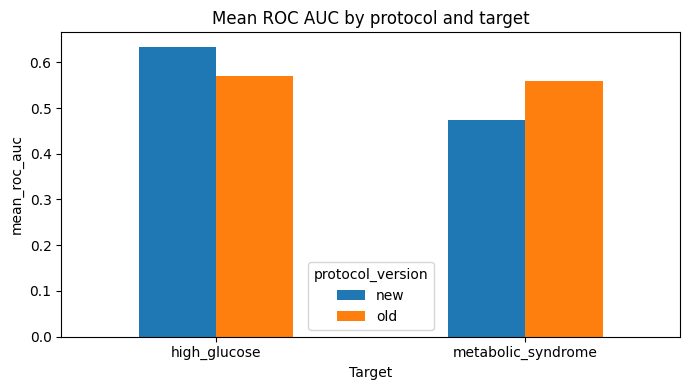

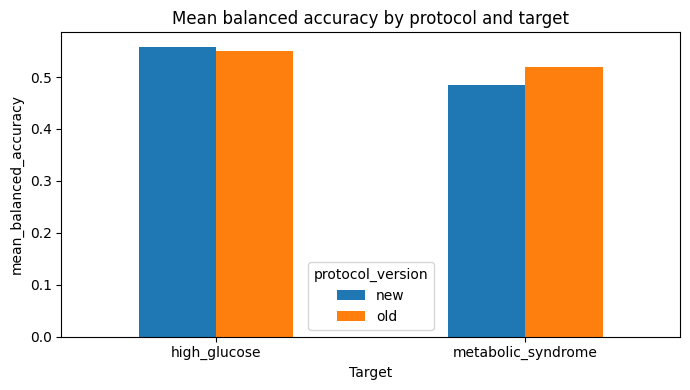

In [220]:
if not supervised_protocol_results_df.empty:
    for metric_col, title in [
        ("mean_roc_auc", "Mean ROC AUC by protocol and target"),
        ("mean_balanced_accuracy", "Mean balanced accuracy by protocol and target"),
    ]:
        plot_df = supervised_protocol_results_df.pivot(
            index="target",
            columns="protocol_version",
            values=metric_col,
        )

        ax = plot_df.plot(kind="bar", figsize=(7, 4))
        ax.set_title(title)
        ax.set_xlabel("Target")
        ax.set_ylabel(metric_col)
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

## 4.9. Frequency-wise exploratory analysis for glucose

Goal:
 - compute simple waveform descriptors at each frequency
 - study their association with continuous glucose (BLOB_Gluc)
 - study their difference by high_glucose group
 - keep the analysis protocol-specific and simple

In [221]:
from scipy.stats import spearmanr

### 4.9.1. Build a light frequency-level feature table

In [222]:
def _build_frequency_feature_table(df):
    """
    Expand the acquisition-level table into a frequency-level table.

    One row = one acquisition x one frequency channel.
    Only simple descriptors are extracted here to keep the analysis compact.
    """
    rows = []

    use_cols = [
        "signal_record_id",
        "protocol_version",
        "site_code",
        "BLOB_Gluc",
        "high_glucose",
        "freq_to_array",
    ]
    use_cols = [c for c in use_cols if c in df.columns]

    for row in df[use_cols].itertuples(index=False):
        if not isinstance(row.freq_to_array, dict):
            continue

        for frequency_hz, signal_array in row.freq_to_array.items():
            arr = np.asarray(signal_array, dtype=float)

            if arr.size == 0:
                continue

            rows.append({
                "signal_record_id": row.signal_record_id,
                "protocol_version": row.protocol_version,
                "site_code": row.site_code if "site_code" in use_cols else pd.NA,
                "frequency_hz": int(frequency_hz),
                "BLOB_Gluc": row.BLOB_Gluc if "BLOB_Gluc" in use_cols else np.nan,
                "high_glucose": row.high_glucose if "high_glucose" in use_cols else np.nan,
                "p2p_freq": float(np.ptp(arr)),
                "rms_freq": float(np.sqrt(np.mean(arr ** 2))),
            })

    return pd.DataFrame(rows)

In [223]:
freq_feature_df = _build_frequency_feature_table(stat_base_df)

# Make sure the clinical variables are numeric
for col in ["BLOB_Gluc", "high_glucose", "p2p_freq", "rms_freq"]:
    if col in freq_feature_df.columns:
        freq_feature_df[col] = pd.to_numeric(freq_feature_df[col], errors="coerce")

print("\nFrequency-level feature table")
display(freq_feature_df.head())



Frequency-level feature table


,signal_record_id,protocol_version,site_code,frequency_hz,BLOB_Gluc,high_glucose,p2p_freq,rms_freq
0,sig_000006,new,B,2000,103.0,1,3.566280,0.302156
1,sig_000006,new,B,1500,103.0,1,4.102365,0.409288
2,sig_000006,new,B,1000,103.0,1,4.190410,0.513669
3,sig_000006,new,B,800,103.0,1,4.191808,0.548183
4,sig_000006,new,B,600,103.0,1,2.924729,0.854694


### 4.9.2. Keep only frequencies present in both protocols

In [224]:
freq_presence_df = (
    freq_feature_df.groupby(["protocol_version", "frequency_hz"], as_index=False)
    .size()
    .rename(columns={"size": "n_rows"})
)

protocol_freq_sets = [
    set(freq_presence_df.loc[freq_presence_df["protocol_version"] == protocol, "frequency_hz"])
    for protocol in sorted(freq_feature_df["protocol_version"].dropna().unique())
]

common_freqs = sorted(set.intersection(*protocol_freq_sets)) if len(protocol_freq_sets) > 0 else []

print("\nCommon frequencies across protocols:")
print(common_freqs)

freq_feature_common_df = freq_feature_df.loc[
    freq_feature_df["frequency_hz"].isin(common_freqs)
].copy()


Common frequencies across protocols:
[400, 600, 800, 1000]


### 4.9.3. Frequency-wise association with continuous glucose Spearman correlation: metric vs BLOB_Gluc

In [225]:
corr_rows = []

for protocol in sorted(freq_feature_common_df["protocol_version"].dropna().unique()):
    for frequency_hz in common_freqs:
        tmp = freq_feature_common_df.loc[
            (freq_feature_common_df["protocol_version"] == protocol) &
            (freq_feature_common_df["frequency_hz"] == frequency_hz),
            ["BLOB_Gluc", "p2p_freq", "rms_freq"]
        ].dropna().copy()

        if len(tmp) < 20:
            continue

        for metric_col in ["p2p_freq", "rms_freq"]:
            rho, p_value = spearmanr(tmp[metric_col], tmp["BLOB_Gluc"])

            corr_rows.append({
                "protocol_version": protocol,
                "frequency_hz": frequency_hz,
                "metric": metric_col,
                "n": int(len(tmp)),
                "spearman_rho": float(rho),
                "p_value": float(p_value),
            })

freq_glucose_corr_df = pd.DataFrame(corr_rows)

if not freq_glucose_corr_df.empty:
    freq_glucose_corr_df["p_fdr"] = multipletests(
        freq_glucose_corr_df["p_value"].values,
        method="fdr_bh",
    )[1]
    freq_glucose_corr_df["significant_fdr_05"] = (
        freq_glucose_corr_df["p_fdr"] < 0.05
    )

    freq_glucose_corr_df = freq_glucose_corr_df.sort_values(
        ["metric", "protocol_version", "frequency_hz"]
    ).reset_index(drop=True)

print("\nFrequency-wise correlations with continuous glucose")
display(freq_glucose_corr_df)



Frequency-wise correlations with continuous glucose


,protocol_version,frequency_hz,metric,n,spearman_rho,p_value,p_fdr,significant_fdr_05
0,new,400,p2p_freq,1504,0.132141,2.704746e-07,4.808438e-07,True
1,new,600,p2p_freq,1504,0.118892,3.775579e-06,4.314947e-06,True
2,new,800,p2p_freq,1504,0.126308,8.922704e-07,1.427633e-06,True
3,new,1000,p2p_freq,1504,0.121806,2.163231e-06,2.662438e-06,True
4,old,400,p2p_freq,1807,0.113016,1.462606e-06,1.950142e-06,True
5,old,600,p2p_freq,1807,0.159760,8.466598e-12,4.515519e-11,True
6,old,800,p2p_freq,1807,0.170088,3.379408e-13,5.407053e-12,True
7,old,1000,p2p_freq,1807,0.160655,6.457270e-12,4.515519e-11,True
8,new,400,rms_freq,1504,0.124034,1.400930e-06,1.950142e-06,True
9,new,600,rms_freq,1504,0.109416,2.113473e-05,2.254372e-05,True


### 4.9.4. Frequency-wise comparison by high_glucose group Mann-Whitney: high_glucose = 0 vs 1

In [226]:
group_rows = []

for protocol in sorted(freq_feature_common_df["protocol_version"].dropna().unique()):
    for frequency_hz in common_freqs:
        for metric_col in ["p2p_freq", "rms_freq"]:
            tmp = freq_feature_common_df.loc[
                (freq_feature_common_df["protocol_version"] == protocol) &
                (freq_feature_common_df["frequency_hz"] == frequency_hz),
                [metric_col, "high_glucose"]
            ].dropna().copy()

            if tmp.empty:
                continue

            group_0 = tmp.loc[tmp["high_glucose"] == 0, metric_col].dropna()
            group_1 = tmp.loc[tmp["high_glucose"] == 1, metric_col].dropna()

            if len(group_0) < 10 or len(group_1) < 10:
                continue

            u_stat, p_value = mannwhitneyu(group_0, group_1, alternative="two-sided")

            group_rows.append({
                "protocol_version": protocol,
                "frequency_hz": frequency_hz,
                "metric": metric_col,
                "n_group_0": int(len(group_0)),
                "n_group_1": int(len(group_1)),
                "median_group_0": float(group_0.median()),
                "median_group_1": float(group_1.median()),
                "delta_median_1_minus_0": float(group_1.median() - group_0.median()),
                "p_value": float(p_value),
            })

freq_high_glucose_df = pd.DataFrame(group_rows)

if not freq_high_glucose_df.empty:
    freq_high_glucose_df["p_fdr"] = multipletests(
        freq_high_glucose_df["p_value"].values,
        method="fdr_bh",
    )[1]
    freq_high_glucose_df["significant_fdr_05"] = (
        freq_high_glucose_df["p_fdr"] < 0.05
    )

    freq_high_glucose_df = freq_high_glucose_df.sort_values(
        ["metric", "protocol_version", "frequency_hz"]
    ).reset_index(drop=True)

print("\nFrequency-wise comparison by high_glucose group")
display(freq_high_glucose_df)


Frequency-wise comparison by high_glucose group


,protocol_version,frequency_hz,metric,n_group_0,n_group_1,median_group_0,median_group_1,delta_median_1_minus_0,p_value,p_fdr,significant_fdr_05
0,new,400,p2p_freq,1352,170,1.385315,4.107568,2.722253,5.497637e-07,1.271063e-06,True
1,new,600,p2p_freq,1352,170,1.202793,3.766844,2.564051,1.125210e-07,9.001682e-07,True
2,new,800,p2p_freq,1352,170,2.119968,4.183699,2.063731,2.315127e-05,3.302097e-05,True
3,new,1000,p2p_freq,1352,170,2.328678,4.177464,1.848787,2.476573e-05,3.302097e-05,True
4,old,400,p2p_freq,1497,340,6.686530,7.007982,0.321452,2.612288e-02,2.786441e-02,True
5,old,600,p2p_freq,1497,340,7.440547,8.159601,0.719054,8.546128e-06,1.367380e-05,True
6,old,800,p2p_freq,1497,340,7.083657,8.030026,0.946369,5.560899e-07,1.271063e-06,True
7,old,1000,p2p_freq,1497,340,6.703711,7.641309,0.937598,9.463896e-07,1.892779e-06,True
8,new,400,rms_freq,1352,170,0.212927,0.678842,0.465915,3.582246e-07,1.271063e-06,True
9,new,600,rms_freq,1352,170,0.322851,1.110675,0.787824,4.785345e-08,7.656551e-07,True


### 4.9.5. Compact plots

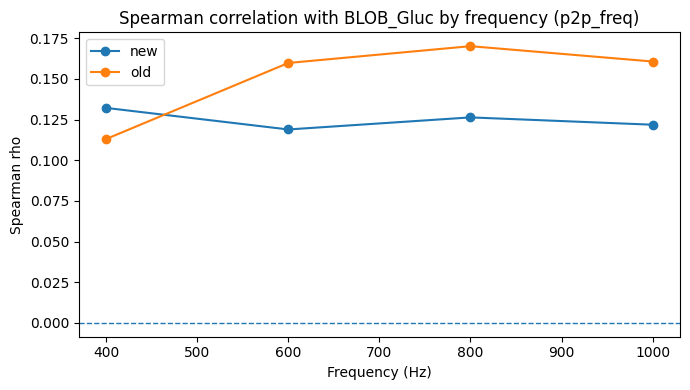

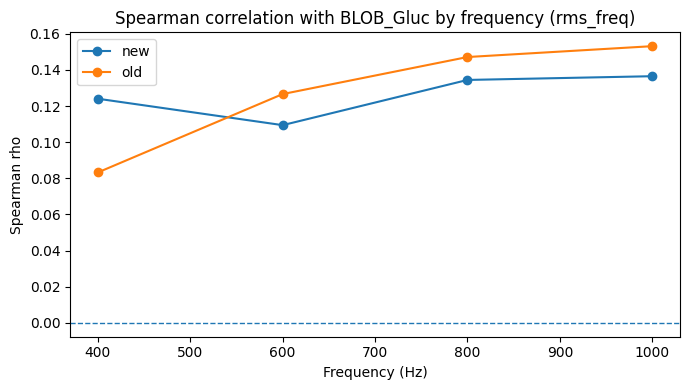

In [227]:
# Correlation with continuous glucose
for metric_col in ["p2p_freq", "rms_freq"]:
    plot_df = freq_glucose_corr_df.loc[
        freq_glucose_corr_df["metric"] == metric_col
    ].copy()

    if plot_df.empty:
        continue

    fig, ax = plt.subplots(figsize=(7, 4))

    for protocol in sorted(plot_df["protocol_version"].dropna().unique()):
        subset_df = plot_df.loc[plot_df["protocol_version"] == protocol]
        ax.plot(
            subset_df["frequency_hz"],
            subset_df["spearman_rho"],
            marker="o",
            label=protocol,
        )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"Spearman correlation with BLOB_Gluc by frequency ({metric_col})")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Spearman rho")
    ax.legend()
    plt.tight_layout()
    plt.show()

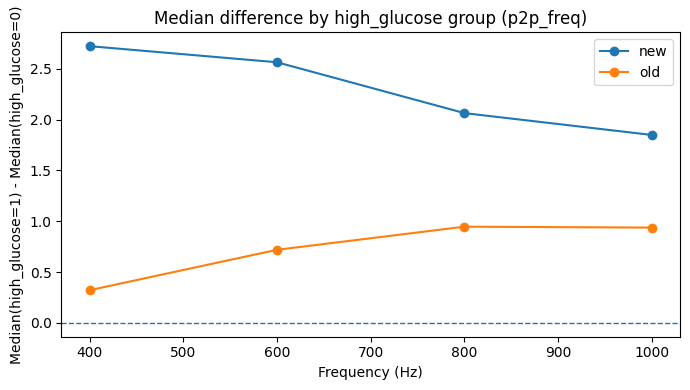

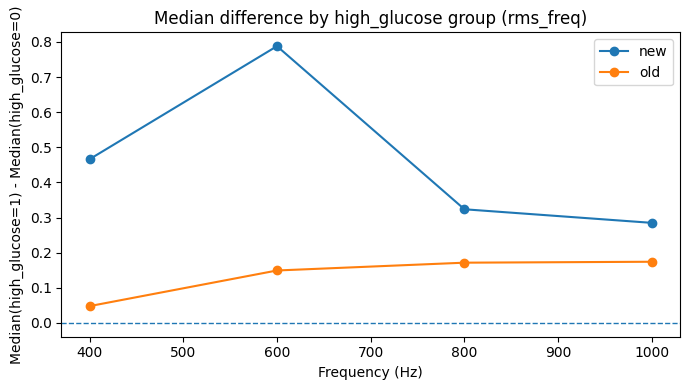

In [228]:
# Group difference for high_glucose
for metric_col in ["p2p_freq", "rms_freq"]:
    plot_df = freq_high_glucose_df.loc[
        freq_high_glucose_df["metric"] == metric_col
    ].copy()

    if plot_df.empty:
        continue

    fig, ax = plt.subplots(figsize=(7, 4))

    for protocol in sorted(plot_df["protocol_version"].dropna().unique()):
        subset_df = plot_df.loc[plot_df["protocol_version"] == protocol]
        ax.plot(
            subset_df["frequency_hz"],
            subset_df["delta_median_1_minus_0"],
            marker="o",
            label=protocol,
        )

    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(f"Median difference by high_glucose group ({metric_col})")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Median(high_glucose=1) - Median(high_glucose=0)")
    ax.legend()
    plt.tight_layout()
    plt.show()

### 4.9.6. Frequency-wise analysis stratified by anatomical site

In [229]:
site_corr_rows = []
site_group_rows = []

site_levels = sorted(freq_feature_common_df["site_code"].dropna().unique())

for protocol in sorted(freq_feature_common_df["protocol_version"].dropna().unique()):
    for site_code in site_levels:
        for frequency_hz in common_freqs:
            tmp_base = freq_feature_common_df.loc[
                (freq_feature_common_df["protocol_version"] == protocol) &
                (freq_feature_common_df["site_code"] == site_code) &
                (freq_feature_common_df["frequency_hz"] == frequency_hz)
            ].copy()

            # A) Correlation with continuous glucose
            tmp_corr = tmp_base[["BLOB_Gluc", "p2p_freq", "rms_freq"]].dropna().copy()

            if len(tmp_corr) >= 20:
                for metric_col in ["p2p_freq", "rms_freq"]:
                    rho, p_value = spearmanr(tmp_corr[metric_col], tmp_corr["BLOB_Gluc"])

                    site_corr_rows.append({
                        "protocol_version": protocol,
                        "site_code": site_code,
                        "frequency_hz": frequency_hz,
                        "metric": metric_col,
                        "n": int(len(tmp_corr)),
                        "spearman_rho": float(rho),
                        "p_value": float(p_value),
                    })

            # B) Difference by high_glucose group
            for metric_col in ["p2p_freq", "rms_freq"]:
                tmp_group = tmp_base[[metric_col, "high_glucose"]].dropna().copy()

                if tmp_group.empty:
                    continue

                group_0 = tmp_group.loc[tmp_group["high_glucose"] == 0, metric_col].dropna()
                group_1 = tmp_group.loc[tmp_group["high_glucose"] == 1, metric_col].dropna()

                if len(group_0) >= 10 and len(group_1) >= 10:
                    u_stat, p_value = mannwhitneyu(group_0, group_1, alternative="two-sided")

                    site_group_rows.append({
                        "protocol_version": protocol,
                        "site_code": site_code,
                        "frequency_hz": frequency_hz,
                        "metric": metric_col,
                        "n_group_0": int(len(group_0)),
                        "n_group_1": int(len(group_1)),
                        "median_group_0": float(group_0.median()),
                        "median_group_1": float(group_1.median()),
                        "delta_median_1_minus_0": float(group_1.median() - group_0.median()),
                        "p_value": float(p_value),
                    })


In [230]:
site_freq_glucose_corr_df = pd.DataFrame(site_corr_rows)
site_freq_high_glucose_df = pd.DataFrame(site_group_rows)

if not site_freq_glucose_corr_df.empty:
    site_freq_glucose_corr_df["p_fdr"] = multipletests(
        site_freq_glucose_corr_df["p_value"].values,
        method="fdr_bh",
    )[1]
    site_freq_glucose_corr_df["significant_fdr_05"] = (
        site_freq_glucose_corr_df["p_fdr"] < 0.05
    )

    site_freq_glucose_corr_df = site_freq_glucose_corr_df.sort_values(
        ["metric", "protocol_version", "site_code", "frequency_hz"]
    ).reset_index(drop=True)

In [231]:
if not site_freq_high_glucose_df.empty:
    site_freq_high_glucose_df["p_fdr"] = multipletests(
        site_freq_high_glucose_df["p_value"].values,
        method="fdr_bh",
    )[1]
    site_freq_high_glucose_df["significant_fdr_05"] = (
        site_freq_high_glucose_df["p_fdr"] < 0.05
    )

    site_freq_high_glucose_df = site_freq_high_glucose_df.sort_values(
        ["metric", "protocol_version", "site_code", "frequency_hz"]
    ).reset_index(drop=True)

In [232]:
print("\nSite-stratified correlations with continuous glucose")
display(site_freq_glucose_corr_df)


Site-stratified correlations with continuous glucose


,protocol_version,site_code,frequency_hz,metric,n,spearman_rho,p_value,p_fdr,significant_fdr_05
0,new,A,400,p2p_freq,497,0.093633,3.691091e-02,4.989015e-02,True
1,new,A,600,p2p_freq,497,0.070284,1.176126e-01,1.347559e-01,False
2,new,A,800,p2p_freq,497,0.093385,3.741761e-02,4.989015e-02,True
3,new,A,1000,p2p_freq,497,0.081705,6.876760e-02,8.686434e-02,False
4,new,B,400,p2p_freq,513,0.144161,1.059098e-03,2.990393e-03,True
5,new,B,600,p2p_freq,513,0.148866,7.186232e-04,2.299594e-03,True
6,new,B,800,p2p_freq,513,0.152869,5.119839e-04,1.890402e-03,True
7,new,B,1000,p2p_freq,513,0.159355,2.904369e-04,1.394097e-03,True
8,new,P,400,p2p_freq,494,0.157697,4.345756e-04,1.738302e-03,True
9,new,P,600,p2p_freq,494,0.133240,3.005825e-03,6.558164e-03,True


In [233]:
print("\nSite-stratified comparison by high_glucose group")
display(site_freq_high_glucose_df)


Site-stratified comparison by high_glucose group


,protocol_version,site_code,frequency_hz,metric,n_group_0,n_group_1,median_group_0,median_group_1,delta_median_1_minus_0,p_value,p_fdr,significant_fdr_05
0,new,A,400,p2p_freq,449,54,2.126064,4.235222,2.109157,0.007878,0.012605,True
1,new,A,600,p2p_freq,449,54,1.993107,4.248146,2.255039,0.003513,0.008030,True
2,new,A,800,p2p_freq,449,54,3.139300,4.218658,1.079358,0.007296,0.012508,True
3,new,A,1000,p2p_freq,449,54,3.240026,4.214213,0.974188,0.009355,0.014486,True
4,new,B,400,p2p_freq,457,62,0.971000,3.447498,2.476498,0.004280,0.008732,True
5,new,B,600,p2p_freq,457,62,0.681890,3.111680,2.429790,0.001157,0.005055,True
6,new,B,800,p2p_freq,457,62,1.400112,4.103337,2.703225,0.014011,0.019780,True
7,new,B,1000,p2p_freq,457,62,1.543180,4.182599,2.639419,0.004725,0.009072,True
8,new,P,400,p2p_freq,446,54,0.996680,3.534712,2.538032,0.000776,0.004655,True
9,new,P,600,p2p_freq,446,54,0.912567,3.284677,2.372110,0.001093,0.005055,True


### 4.9.7. Compact summaries

In [234]:
if not site_freq_glucose_corr_df.empty:
    print("\nStrongest site-stratified correlations with continuous glucose")
    display(
        site_freq_glucose_corr_df.assign(
            abs_rho=lambda d: d["spearman_rho"].abs()
        )
        .sort_values(["p_fdr", "abs_rho"], ascending=[True, False])
        .drop(columns="abs_rho")
        .head(20)
    )


Strongest site-stratified correlations with continuous glucose


,protocol_version,site_code,frequency_hz,metric,n,spearman_rho,p_value,p_fdr,significant_fdr_05
14,old,A,800,p2p_freq,690,0.263501,2.010952e-12,9.652571e-11,True
15,old,A,1000,p2p_freq,690,0.258272,5.611801e-12,1.346832e-10,True
39,old,A,1000,rms_freq,690,0.239957,1.711329e-10,2.738127e-09,True
13,old,A,600,p2p_freq,690,0.233455,5.392773e-10,6.471328e-09,True
38,old,A,800,rms_freq,690,0.221321,4.200174e-09,4.032167e-08,True
37,old,A,600,rms_freq,690,0.184490,1.064580e-06,8.516643e-06,True
31,new,B,1000,rms_freq,513,0.176824,5.650010e-05,3.874293e-04,True
30,new,B,800,rms_freq,513,0.174634,6.999104e-05,4.004419e-04,True
12,old,A,400,p2p_freq,690,0.150155,7.508286e-05,4.004419e-04,True
7,new,B,1000,p2p_freq,513,0.159355,2.904369e-04,1.394097e-03,True


In [235]:
if not site_freq_high_glucose_df.empty:
    print("\nLargest site-stratified differences by high_glucose group")
    display(
        site_freq_high_glucose_df.assign(
            abs_delta=lambda d: d["delta_median_1_minus_0"].abs()
        )
        .sort_values(["p_fdr", "abs_delta"], ascending=[True, False])
        .drop(columns="abs_delta")
        .head(20)
    )


Largest site-stratified differences by high_glucose group


,protocol_version,site_code,frequency_hz,metric,n_group_0,n_group_1,median_group_0,median_group_1,delta_median_1_minus_0,p_value,p_fdr,significant_fdr_05
14,old,A,800,p2p_freq,555,144,6.902360,8.431140,1.528780,0.000005,0.000248,True
15,old,A,1000,p2p_freq,555,144,6.591511,8.330309,1.738798,0.000017,0.000412,True
39,old,A,1000,rms_freq,555,144,0.975685,1.217130,0.241444,0.000051,0.000818,True
13,old,A,600,p2p_freq,555,144,7.291166,8.427939,1.136773,0.000085,0.001017,True
25,new,A,600,rms_freq,449,54,0.563233,1.357739,0.794506,0.000141,0.001357,True
38,old,A,800,rms_freq,555,144,1.105905,1.336686,0.230781,0.000199,0.001593,True
8,new,P,400,p2p_freq,446,54,0.996680,3.534712,2.538032,0.000776,0.004655,True
31,new,B,1000,rms_freq,457,62,0.173523,0.510195,0.336672,0.000708,0.004655,True
5,new,B,600,p2p_freq,457,62,0.681890,3.111680,2.429790,0.001157,0.005055,True
9,new,P,600,p2p_freq,446,54,0.912567,3.284677,2.372110,0.001093,0.005055,True


### 4.9.8. Simple plots by site

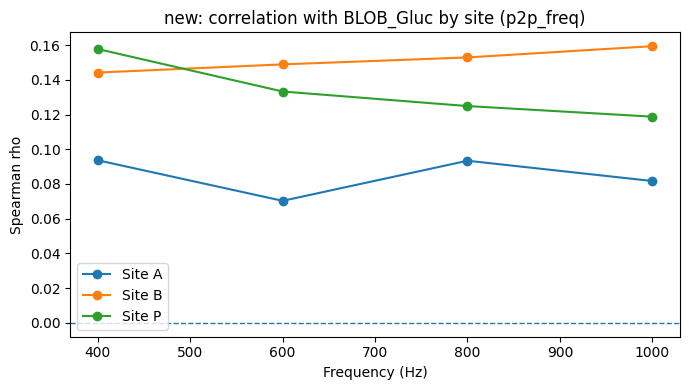

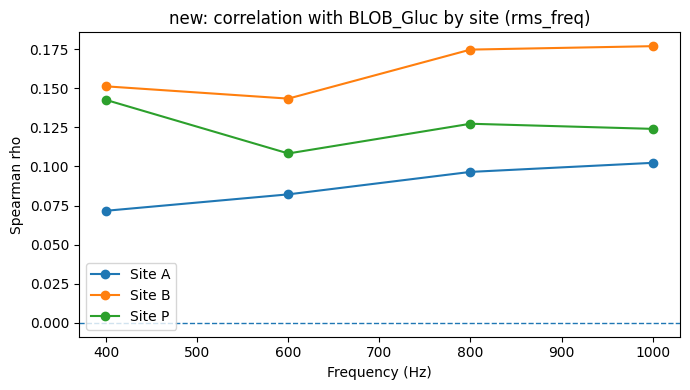

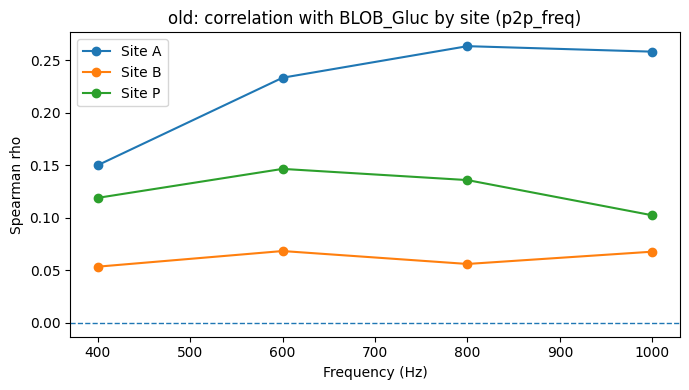

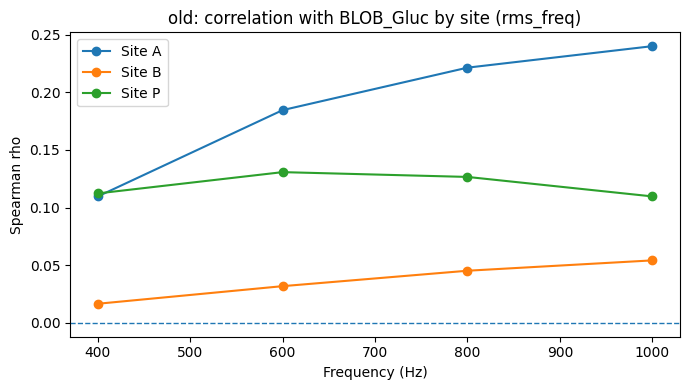

In [236]:
for protocol in sorted(freq_feature_common_df["protocol_version"].dropna().unique()):
    for metric_col in ["p2p_freq", "rms_freq"]:
        plot_df = site_freq_glucose_corr_df.loc[
            (site_freq_glucose_corr_df["protocol_version"] == protocol) &
            (site_freq_glucose_corr_df["metric"] == metric_col)
        ].copy()

        if plot_df.empty:
            continue

        fig, ax = plt.subplots(figsize=(7, 4))

        for site_code in sorted(plot_df["site_code"].dropna().unique()):
            subset_df = plot_df.loc[plot_df["site_code"] == site_code]
            ax.plot(
                subset_df["frequency_hz"],
                subset_df["spearman_rho"],
                marker="o",
                label=f"Site {site_code}",
            )

        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_title(f"{protocol}: correlation with BLOB_Gluc by site ({metric_col})")
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Spearman rho")
        ax.legend()
        plt.tight_layout()
        plt.show()


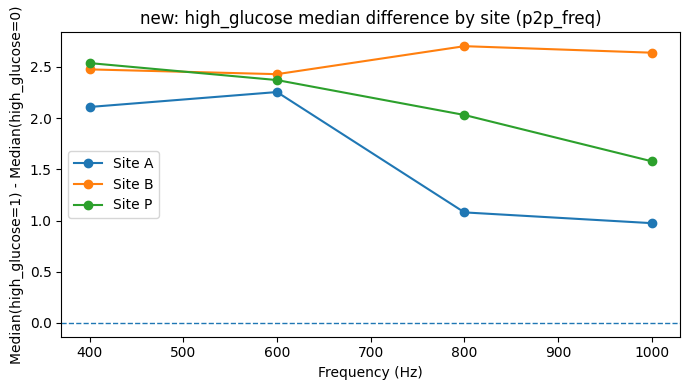

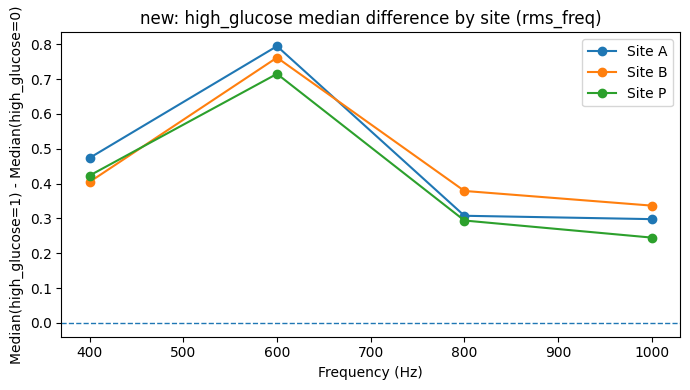

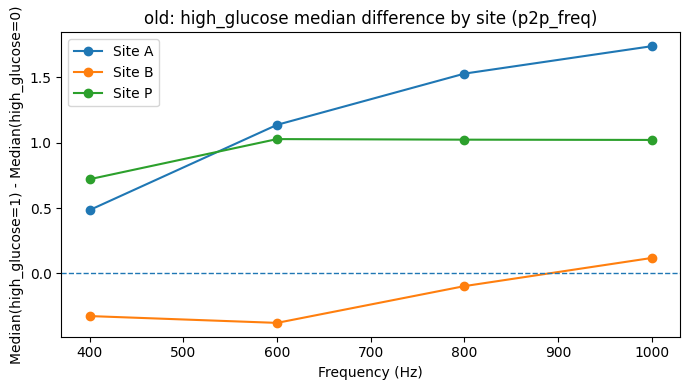

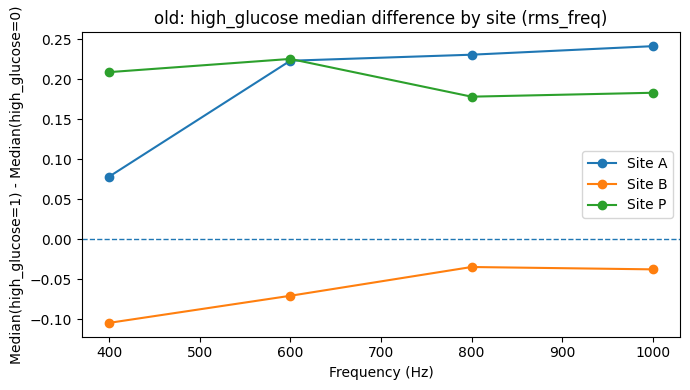

In [237]:
for protocol in sorted(freq_feature_common_df["protocol_version"].dropna().unique()):
    for metric_col in ["p2p_freq", "rms_freq"]:
        plot_df = site_freq_high_glucose_df.loc[
            (site_freq_high_glucose_df["protocol_version"] == protocol) &
            (site_freq_high_glucose_df["metric"] == metric_col)
        ].copy()

        if plot_df.empty:
            continue

        fig, ax = plt.subplots(figsize=(7, 4))

        for site_code in sorted(plot_df["site_code"].dropna().unique()):
            subset_df = plot_df.loc[plot_df["site_code"] == site_code]
            ax.plot(
                subset_df["frequency_hz"],
                subset_df["delta_median_1_minus_0"],
                marker="o",
                label=f"Site {site_code}",
            )

        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_title(f"{protocol}: high_glucose median difference by site ({metric_col})")
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Median(high_glucose=1) - Median(high_glucose=0)")
        ax.legend()
        plt.tight_layout()
        plt.show()